In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import seaborn as sns
import math
#from plotnine import *
#import scvi
import os
#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
%matplotlib inline
sc.settings.verbosity = 0




In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline

sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(14,14))


# scRNA - CORE DATA

In [13]:
# #adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.v8_nohealthy')
# PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.nohealthy'
# adata=sc.read_h5ad(PATH)
# adata.obs["Site_status"].value_counts()
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')


In [14]:
adata = adata[(adata.obs["lvl5_annotation"]=="Eosinophil")|
             (adata.obs["lvl5_annotation"].str.startswith("Mast cell"))|
              (adata.obs["lvl5_annotation"]=="Neutrophil")
              
              
                 ].copy()


In [6]:
# KEEP = ["PostRx-Lesional Dupilumab (1 yr)",
#         'PostRx-Lesional Dupilumab (16 wk)',
#         "Week 12","3D_Week12", "3D_Lesional_baseline",
#         "Lesional"]
        
# adata_i=adata[adata.obs["Site_status"].isin(KEEP)]
# adata_i=adata_i[adata_i.obs["lvl5_annotation"]=="TRM_IL13+"].copy()
# adata_i.obs["Patient_status"].value_counts()

In [7]:
# adata.obs.Site_status.value_counts()

In [8]:
# adata = adata[(adata.obs["Patient_status"]=="AD")].copy()


In [9]:
# adata = adata[adata.obs["Site_status"]=="Lesional"].copy()


In [10]:
22

22

In [11]:
# KEEP = ["PostRx-Lesional Dupilumab (1 yr)",
#         'PostRx-Lesional Dupilumab (16 wk)',
#         "Week 12","3D_Week12", "3D_Lesional_baseline",
#         "Lesional"]
        
# adata_i=adata[adata.obs["Site_status"].isin(KEEP)]
# adata_i=adata_i[adata_i.obs["lvl5_annotation"]=="TRM_IL13+"].copy()
# adata_i.obs["Patient_status"].value_counts()

In [13]:

# #adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
# adata=adata[adata.obs["tech"]!="xenium"].copy()

# #adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
# import gc
# gc.collect()

In [14]:
# adata[adata.obs["Site_status"]=="Lesional"]

In [15]:
# adata_5k.obs.Site_status.value_counts()

In [20]:
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST






In [16]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



In [18]:
# sc.pp.normalize_total(adata_5k, target_sum=1e4)
# sc.pp.log1p(adata_5k)

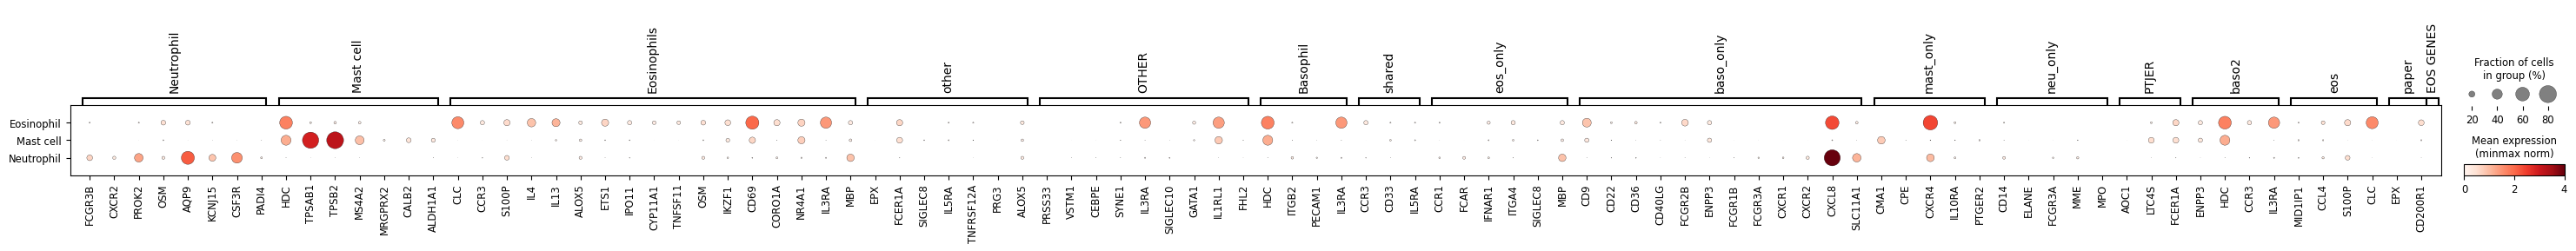

In [17]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13", "ALOX5",
    "ETS1",
   # "KLF5",
   # "NTRK1",
   # "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM", "IKZF1",
    "CD69",
     
    "CORO1A",
   
    "NR4A1",
   
    "IL3RA","MBP"
                           ],
        
        "other": ["EPX", "FCER1A", "SIGLEC8", "IL5RA",
                 "TNFRSF12A", "PRG3", "ALOX5"
                 ],
        "OTHER": [
    "PRSS33",
    "VSTM1",
    "CEBPE",
    "SYNE1",
    "IL3RA",
    "SIGLEC10",
    "GATA1",
    "IL1RL1",
    "FHL2",
],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3", 
                  'FCGR1B', 'FCGR3A', 
                  'CXCR1', 'CXCR2', 'CXCL8', 
                  'SLC11A1'
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"],
        "EOS GENES":  [
    
]
            }
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )



In [23]:
adata.var

""
MIR1302-2HG
FAM138A
OR4F5
AL627309.1
AL627309.3
...
AC233755.2
AC233755.1
AC240274.1
AC213203.2


In [30]:
genes0

0         PRG2
1        PLIN2
2         IL1B
3        CXCL8
4       CALCRL
5         IL13
6        CXCL2
7        CXCR4
8        HMGB2
9      TNFAIP8
10       SRSF2
11        CYCS
12        PTX3
13       ITM2A
14      EIF4A1
15       NFKB1
16       ITGA4
17        SFPQ
18      SLC7A5
19      NFE2L2
20      FCER1A
21      BCL2A1
22       HSPD1
23       U2AF1
24       STMN1
25      SNRPD1
26        AIF1
27        CYBA
28        TOP1
29      ATP2B1
30       HMGA1
31    MAP1LC3B
32        PGK1
33       RUNX1
34         FUS
35      DNAJA1
36       HSPA8
37       SNHG1
38       PSIP1
39      UBE2D3
40       ROCK1
41        CCT5
42     SMARCC1
43       ICAM1
44        ZEB2
45      CEMIP2
46        SOD1
47        XBP1
48         PGD
49         BID
Name: IC: Eosinophil, dtype: object

In [38]:
remove_markers(list(genes2))

['TET2',
 'ANKRD44',
 'VSTM1',
 'TYMP',
 'CNR2',
 'SLC29A1',
 'ALOX5',
 'MINDY1',
 'IL1B',
 'CKAP4',
 'IRS2',
 'JAK2',
 'MBP',
 'PLD1',
 'LASP1',
 'NFKB1',
 'CD47',
 'PIK3CB',
 'FAM110A',
 'OLIG1',
 'NIBAN1',
 'IKZF2',
 'SLC7A5',
 'NFE2L2',
 'DACH1',
 'XPO6',
 'SORL1',
 'FBXW7',
 'NCOA4',
 'DDX6',
 'NLRC5',
 'CFLAR',
 'ITGAL',
 'RELT',
 'SRPK1',
 'SEMA4C',
 'ZC3H12A',
 'EPAS1',
 'CREBBP',
 'SLC12A6',
 'TOP1',
 'HCAR2',
 'IKZF1',
 'TLR4',
 'PDE4B',
 'PDCD6IP',
 'TNFSF10',
 'NEDD9',
 'SELPLG',
 'WBP2']

In [3]:
BASO_GENES2 = ['TET2',
 'ANKRD44',
 'VSTM1',
 'TYMP',
 'CNR2',
 'SLC29A1',
 'ALOX5',
 'MINDY1',
 'IL1B',
 'CKAP4',
 'IRS2',
 'JAK2',
 'MBP',
 'PLD1',
 'LASP1',
 'NFKB1',
 'CD47',
 'PIK3CB',
 'FAM110A',
 'OLIG1',
 'NIBAN1',
 'IKZF2',
 'SLC7A5',
 'NFE2L2',
 'DACH1',
 'XPO6',
 'SORL1',
 'FBXW7',
 'NCOA4',
 'DDX6',
 'NLRC5',
 'CFLAR',
 'ITGAL',
 'RELT',
 'SRPK1',
 'SEMA4C',
 'ZC3H12A',
 'EPAS1',
 'CREBBP',
 'SLC12A6',
 'TOP1',
 'HCAR2',
 'IKZF1',
 'TLR4',
 'PDE4B',
 'PDCD6IP',
 'TNFSF10',
 'NEDD9',
 'SELPLG',
 'WBP2']

In [4]:
BASO_GENES1= ['TENT5C',
 'EVI2B',
 'RAB27A',
 'VASP',
 'GAB2',
 'TRPM6',
 'ATP2B1',
 'PMAIP1',
 'ARRB2',
 'MAPK14',
 'PILRA',
 'MBNL1',
 'NTRK1',
 'ACAP1',
 'CTSA',
 'NCF4',
 'FOXO3',
 'STK4',
 'ITGA2B',
 'JAZF1',
 'NLRP1',
 'CYLD',
 'ITGB7',
 'SPTBN1',
 'ZFAND5',
 'CCND3',
 'ITGAM',
 'TFE3',
 'LYZ',
 'ZYX',
 'C5AR1',
 'PLIN2',
 'PIM1',
 'RASSF2',
 'TNFAIP8',
 'CCR3',
 'CD244',
 'ANXA2',
 'OSM',
 'SELL',
 'TES',
 'CEBPA',
 'FCGR2B',
 'OXSR1',
 'LYN',
 'PIM2',
 'PLEKHA2',
 'GRB2',
 'IVNS1ABP',
 'MSN']

In [5]:
BASO_GENES0 = ['CXCR4',
 'NCF1',
 'IL3RA',
 'CSF2RB',
 'ADAM8',
 'S100P',
 'PLAUR',
 'MYO1F',
 'CR1',
 'MXD1',
 'PADI4',
 'HCAR3',
 'ATP10D',
 'MYH9',
 'IL17RA',
 'CD55',
 'RUNX1',
 'ITGB2',
 'PGD',
 'TMEM164',
 'PTK2B',
 'MAX',
 'CYBA',
 'PICALM',
 'SULF2',
 'CXCL8',
 'PTPRC',
 'ICAM3',
 'PRKCD',
 'PYGL',
 'NCF2',
 'VSIR',
 'MYD88',
 'TGFBR2',
 'PNPLA6',
 'PAPSS1',
 'JAK1',
 'KDM6B',
 'IFITM1',
 'IRF1',
 'SERPINB2',
 'G6PD',
 'TKT',
 'PLP2',
 'STAT4',
 'KLF5',
 'RASSF5',
 'PTX3',
 'PNPLA2',
 'FNDC3B']

In [6]:
EOS_GENES0 = ['PRG2',
 'PLIN2',
 'IL1B',
 'CXCL8',
 'CALCRL',
 'IL13',
 'CXCL2',
 'CXCR4',
 'HMGB2',
 'TNFAIP8',
 'SRSF2',
 'CYCS',
 'PTX3',
 'ITM2A',
 'EIF4A1',
 'NFKB1',
 'ITGA4',
 'SFPQ',
 'SLC7A5',
 'NFE2L2',
 'FCER1A',
 'BCL2A1',
 'HSPD1',
 'U2AF1',
 'STMN1',
 'SNRPD1',
 'AIF1',
 'CYBA',
 'TOP1',
 'ATP2B1',
 'HMGA1',
 'MAP1LC3B',
 'PGK1',
 'RUNX1',
 'FUS',
 'DNAJA1',
 'HSPA8',
 'PSIP1',
 'UBE2D3',
 'ROCK1',
 'CCT5',
 'SMARCC1',
 'ICAM1',
 'ZEB2',
 'CEMIP2',
 'SOD1',
 'XBP1',
 'PGD',
 'BID']

In [7]:
EOS_GENES1 = ['ARF1',
 'IRF1',
 'GNAI2',
 'CREG1',
 'SNHG8',
 'EIF4EBP2',
 'STAT4',
 'NUCB2',
 'CNOT1',
 'IL5RA',
 'NR4A3',
 'NRIP1',
 'HSPA9',
 'SEC13',
 'PRKDC',
 'EZH2',
 'HELLS',
 'SKP1',
 'EIF5A',
 'PPP2CA',
 'LDHA',
 'NLRP3',
 'REL',
 'CSRP1',
 'GRB2',
 'RAB11A',
 'DDX21',
 'APOE',
 'EEF1G',
 'MMADHC',
 'TCP1',
 'NINJ1',
 'PTGES3',
 'AKR1B1',
 'CKS2',
 'IMMT',
 'CSF2RB',
 'IGF2BP2',
 'NR3C1',
 'BCL3',
 'MFF',
 'ALYREF',
 'DIS3',
 'IL4',
 'DEK',
 'GATA1',
 'ATP5F1C',
 'SMARCA5',
 'PLP2',
 'RSRC1']

In [8]:
EOS_GENES2 = ['PLAUR',
 'CD7',
 'SEPTIN6',
 'FLT1',
 'SQSTM1',
 'HNRNPF',
 'TES',
 'CDKN1C',
 'NDUFAB1',
 'XRCC5',
 'TFPI',
 'RELB',
 'CHEK1',
 'DNMT1',
 'CDC42',
 'RRM2',
 'KPNA2',
 'DAZAP2',
 'HNRNPUL1',
 'HNRNPM',
 'FNDC3B',
 'PPIF',
 'FBL',
 'IMPDH2',
 'ZFAND5',
 'RAC1',
 'RHEB',
 'EIF1AY',
 'BCL2L12',
 'TUBB',
 'RBX1',
 'EID1',
 'FBXW11',
 'ATF3',
 'KRT15',
 'CD83',
 'SRSF1',
 'SPI1',
 'GSTO1',
 'NUDT1',
 'RCOR1',
 'GNAQ',
 'GHITM',
 'RBMX',
 'IKZF2',
 'VASP',
 'TXNRD1',
 'PRR13',
 'EIF1B',
 'KDM6B']

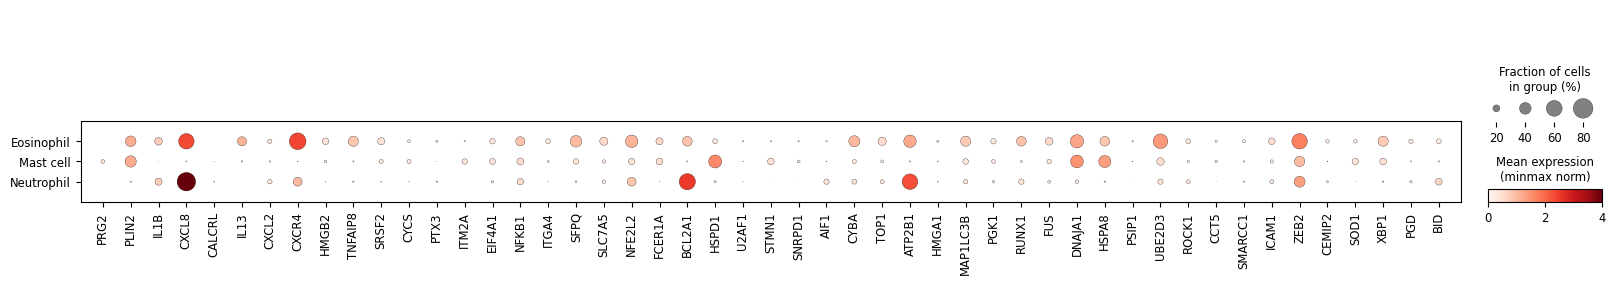

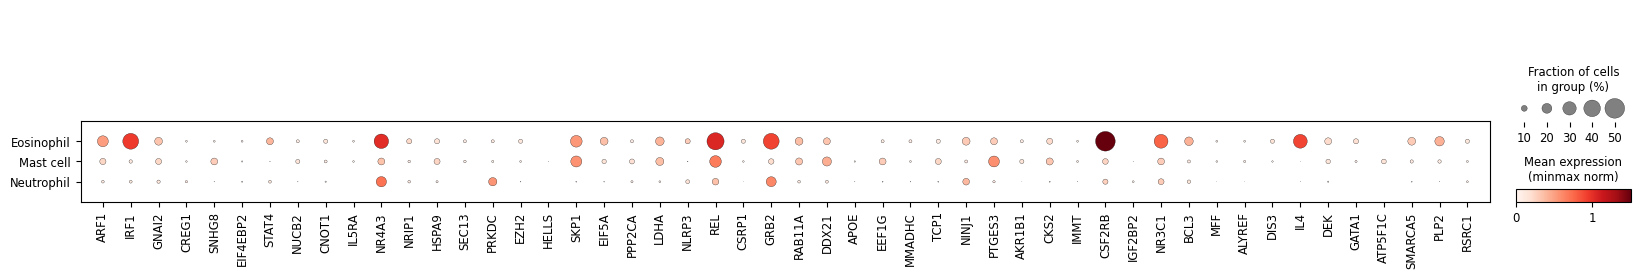

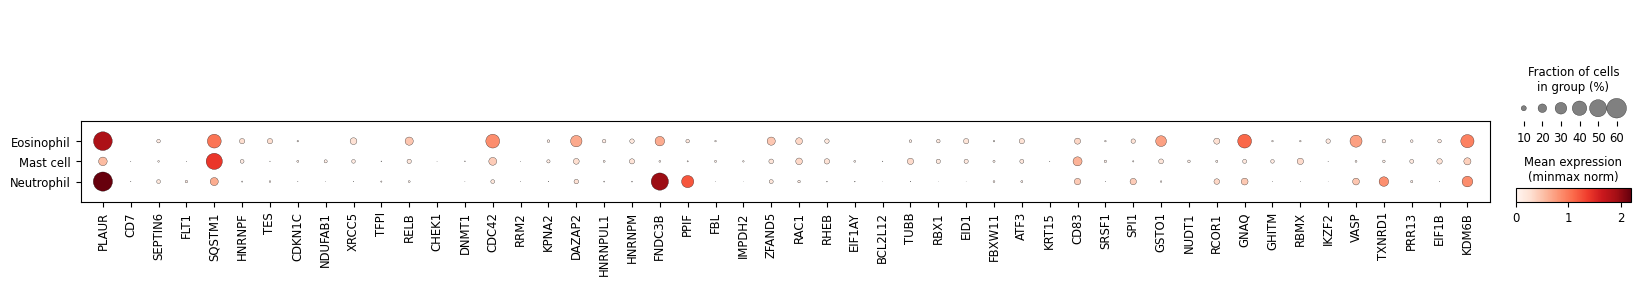

In [31]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              remove_markers(list(genes0)),
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              remove_markers(list(genes1)),
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              remove_markers(list(genes2)),
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )




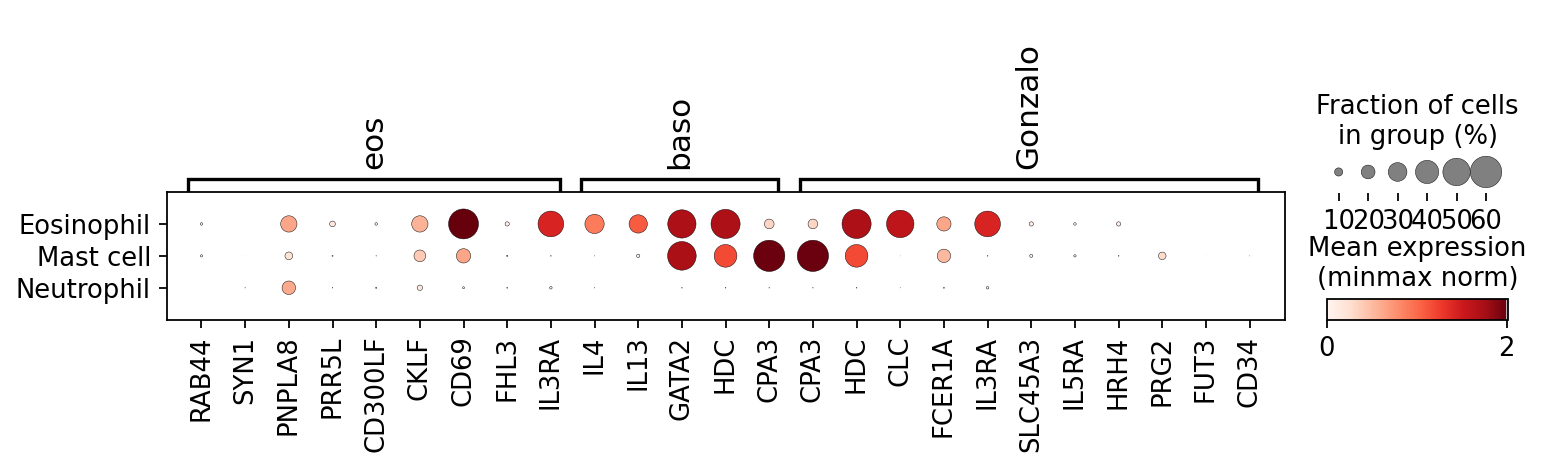

In [9]:
genes_dict = {
    "eos": ["RAB44", "SYN1", "PNPLA8", "PRR5L", "CD300LF", "CKLF", "CD69", "FHL3", "IL3RA"],
    "baso": ["IL4", "IL13", "GATA2", "HDC", "CPA3"],

    "FERI": ["PRG2", "IL5RA", "IL3RA"],
    "Gonzalo": [
    "CPA3",
    "HDC",
    "CLC",
    "FCER1A",
    "IL3RA",
    "SLC45A3",
    "IL5RA",
    "HRH4",
    "PRG2",
    "FUT4",
    "CD34",
],
}
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              genes_dict,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )



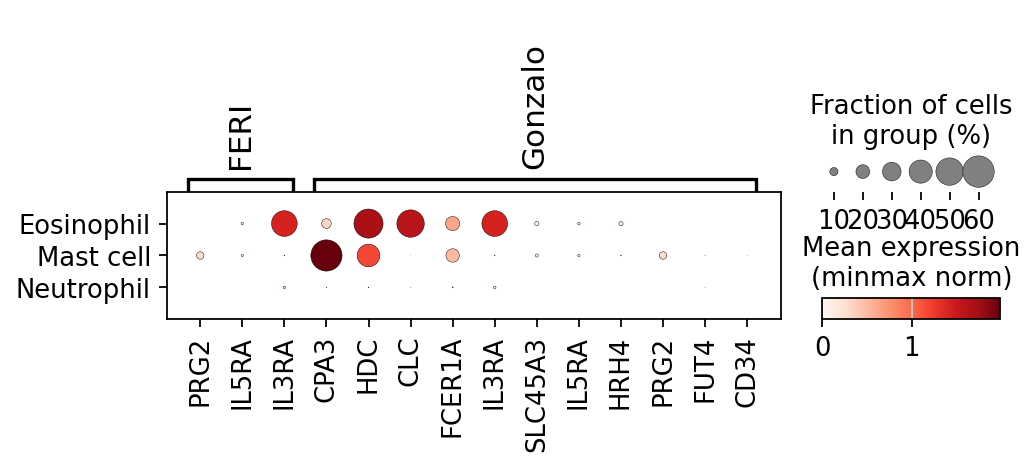

In [12]:
genes_dict = {
    "FERI": ["PRG2", "IL5RA", "IL3RA"],
    "Gonzalo": [
    "CPA3",
    "HDC",
    "CLC",
    "FCER1A",
    "IL3RA",
    "SLC45A3",
    "IL5RA",
    "HRH4",
    "PRG2",
    "FUT4",
    "CD34",
],
}

sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              genes_dict,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )


In [57]:
adata=adata[adata.obs["lvl5_annotation"]!="Mast cell"].copy()
adata=adata[adata.obs["lvl5_annotation"]!="Neutrophil"].copy()

# Prenatal skin data

In [9]:
# !pip install -U anndata scanpy

In [10]:
# 1

In [11]:
# !pip install scanpy

In [12]:
# import scanpy as sc
# PATH = '/nfs/team298/ft4/projects/fetalskin_regionalid/intermediate_data/nobackup_data/eos_baso_mast_regional_id_for_lloyd.h5ad'
# adata=sc.read_h5ad(PATH
#                  # flavor= 'stereopy'
#                   )


In [13]:
adata

AnnData object with n_obs × n_vars = 2782 × 5066
    obs: 'sanger_id', 'sample_name', 'hdbr_id', 'digestion', 'sorting method', '_is_sorted', 'sorting_perc', 'loading_perc', 'pcw_age', 'anatomical_site_lvl1', 'anatomical_site_lvl2', 'age_site_lvl1', 'age_site_lvl2', 'kit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'sanger_ID', 'outlier', 'outlier_pct_ribo', 'QC', 'unint_leiden_res_1', 'age_group', 'broad_annot_suggestions', '_scvi_batch', '_scvi_labels', 'scanvi_pred', 'scvi_leiden_res1', 'fine_annot_manual', 'mid_annot_manual', 'annot_lvl2', 'annot_lvl1', 'annot_lvl3', 'sc_xenium_subset', 'annot_lvl1_scvi_majority', 'scvi_annot_lvl3', 'scvi_annot_lvl2', 'scvi_annot_lvl1', 'sam

In [5]:
del(adata.obsm)
del(adata.layers)
del(adata.uns)

In [6]:
# adata.write('/nfs/team298/ls34/adult_skin/final_adatas/adata_prenatal_granulocyte.h5ad')


In [14]:

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
 EOS_GENES2

In [15]:
adata

AnnData object with n_obs × n_vars = 2782 × 5066
    obs: 'sanger_id', 'sample_name', 'hdbr_id', 'digestion', 'sorting method', '_is_sorted', 'sorting_perc', 'loading_perc', 'pcw_age', 'anatomical_site_lvl1', 'anatomical_site_lvl2', 'age_site_lvl1', 'age_site_lvl2', 'kit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'sanger_ID', 'outlier', 'outlier_pct_ribo', 'QC', 'unint_leiden_res_1', 'age_group', 'broad_annot_suggestions', '_scvi_batch', '_scvi_labels', 'scanvi_pred', 'scvi_leiden_res1', 'fine_annot_manual', 'mid_annot_manual', 'annot_lvl2', 'annot_lvl1', 'annot_lvl3', 'sc_xenium_subset', 'annot_lvl1_scvi_majority', 'scvi_annot_lvl3', 'scvi_annot_lvl2', 'scvi_annot_lvl1', 'sam

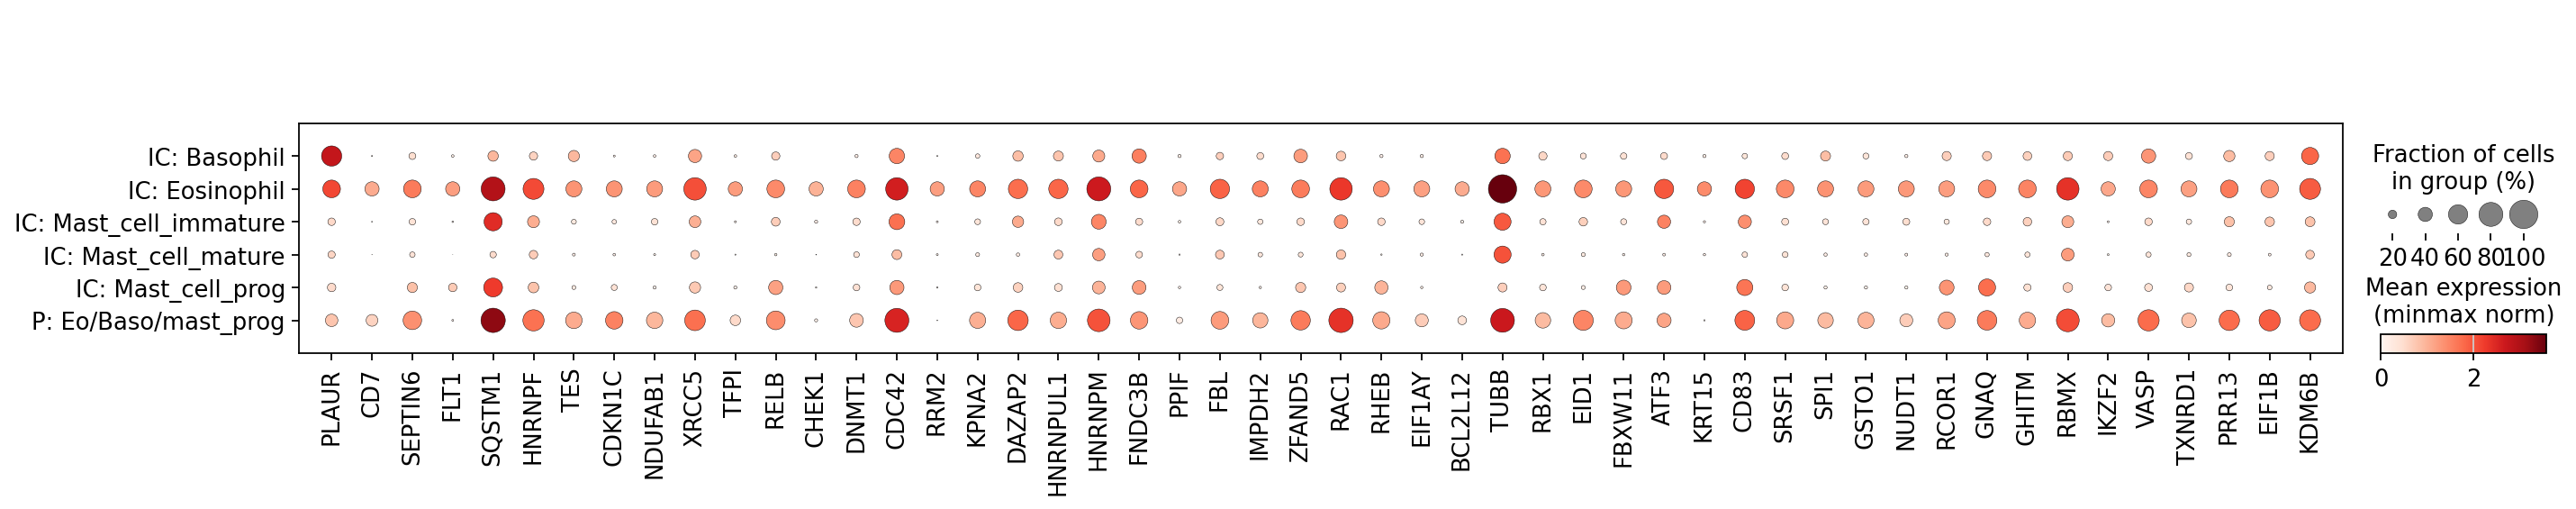

In [21]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              EOS_GENES2,
              groupby="scanvi_pred_fine_curated",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


In [23]:
PRENATAL_GENES = {"BASOPHIL ONLY": ["PADI4", "NCF2", "TRMP6", "ITGB7", "CCR3",
                                   "NLRC5", "VSTM1"
                                   ],
                    "BASOPHIL MOSTLY": ["NCF1", "IL3RA", "S100P",
                                       "CR1", "MYO1F", "SULF2", 
                                       ],
                  "EOS": ["CALCRL", "IL13", "CXCL2", "CEMIP2", "HELLS", "CREG1", 
                         "IL4", "CD7", "BCL21L2"
                         ]
                         
    
}

In [1]:
9

9

# PAN-DISEASE ATLAS

In [3]:
import scanpy as sc
PATH = '/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_data/model_scanvi5_atlasv2_nojunk_5861/adata_all_scvi5.h5ad.withjunk'
#PATH =  "/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/adata_atlas_incxenium_v5.h5ad"
adata=sc.read_h5ad(PATH)

/software/cellgen/team298/ls34/cookiecutter/lib/python3.11/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [2]:
adata

AnnData object with n_obs × n_vars = 3162521 × 36610
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'lvl1_new', 'orig.ide

In [5]:
adata

AnnData object with n_obs × n_vars = 3162521 × 36610
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'lvl1_new', 'orig.ide

In [4]:
import pickle

try:
    file_path = "/nfs/team298/ls34/dicts/color_for_adult_skin2.pkl"
    with open/(file_path, "rb") as f:
        colors = pickle.load(f)
except:
    !wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
         -O color_for_adult_skin2.pkl
    file_path = "./color_for_adult_skin2.pkl"
    with open(file_path, "rb") as f:
        colors = pickle.load(f)
colors= colors | {'New/unlabelled/excluded': "#C8C8C8",
                  'New/unlabelled/unspecific':  "#C8C8C8",
                  'F1: Superficial': '#ffef5a',
    'F2/3: Perivascular': '#364f99',
    'F2: Universal': '#91bae2',
    'F3: FRC-like': '#c6508f',
    'F4: DP_HHIP+': '#c9efb4',
    'F4: DS_DPEP1+': '#3d6f3b',
    'F4: TNN+COCH+': '#00f273',
    'F5: NGFR+': '#8981a7',
    'F5: RAMP1+': '#4b2657',
     'F6: Inflammatory myofibroblast': "#75fbfd",
     'F7: Myofibroblast': "#2f6565",
       'F8: Fascia-like myofibroblast':"#EFA093", #'#dd7465',
 'F_Fascia': "#00004D",
                     "Th2": "#2A6072",      # Dark Blue (classic, strong contrast)
    "Tfh-like": "#AAA9A9",  # Neon Blue (bright, electric tone)
    "Th17": "#FFB3B3",
                  "adipocyte": '#B8860B'

     #   "TRM_IL13+": "#7D93C7"
    
                               } 
print(f"Loaded {len(colors)} colour entries")
colors2 = {'Sweat gland_clear': '#8AEAEA',
 'Sweat gland_dark': '#006D6D',

 'LE1': '#FFFF2B',

 'MacTREM2hi': '#E9E2F0',
 'LE2': '#D5D500',
 'Scar_VE/Peri': '#FF9B9B',
 'Mac2_MMP19hi': '#DDD3E9',
 'Mast cell_Active_ABCC4hi': '#FFB14D',
 'Mac2_HRH1+': '#D2C4E2',
 'KC3*': '#758BCC',
 'KC1/2_cycling': '#e0c5d2',
 'KC4/5': '#272c5f',
 'KC4*': '#9FC2CD',
 'KC_HFSC': '#D600FF',
 'T_CD4ex': '#FFE8B3',
            'ASIC2+ Mechanoreceptor': '#F1F1F1',
            'lowq': '#F1F1F1',
                       'new': '#F1F1F8',


 'ASIC2+ Mechanoreceptor2': '#F1F1F1',
 'Tfh-like2': '#AAA9A9',
 'ASIC1_4_KIF5C+': '#6F6F6F',
 'TRM_ex': '#FFF8E1',
 'Mast cell_prolif': '#FFA64D',
 'Th17/IFNGhi': '#FFA000',
 'Tc1_GIMAPhi': '#FFD06A',
 'KC_HF: ORS_KLK8+_SRGN+': '#E8FFF0',
 'ASIC2+ Mechanoreceptor1': '#D9D9D9',
 'Tfh-like1': '#AAB7C3',
 'Th_IFNGhi': '#FFB00A',
 'T DC Doublet': '#B38066',
 'SCC_KC': '#7B9299',
 'Melanoma': '#4E3323',
 'BCC+SCC_KC': '#576166',
 'Merkel_KC': '#FFE5E5'}
colors=colors|colors2
COLORS = {
    "ILC3+CCL1+PTGDS+": "#FF2F92",        # neon pink
    "ILC1_Prolif": "#FFD800",             # bright yellow
    "Tγδ": "#8B5A2B",                     # brown
    "CD4+_Prolif": "#C2B280",             # dark beige
    "CD4_IL13+ (was TRM_IL17+)": "#87CEEB",# sky blue
    "Th(ribosomal)": "#F2E6D8",            # very pale beige
    "Tc3_IFNGhi_CCL3+": "#E6D3B1",         # neon-ish beige
    "Tc1_BACH2+": "#E39A2E",               # orange beige
    "Th_PPARGhi_SLC10A1+TNFhi": "#9BB7D4", # bluish beige
    "Tc2_GZMH+": "#F28C28",                # orange
    "Tc3_IFNGhi_exhausted": "#FFE5C4",     # very pale orange
    "CD4_Tex_GZMK+IL10+PDCD1+": "#EFE2CF", # very pale beige
    "ILC3_Early": "#F6B7C6",               # pale pink
    "Th17_CCL20+ZBTB16+LAYN+": "#6FBF73",  # greenish
    "Th1_KLRG1+": "#D8C4A8",               # beige
    "Tc2_GZMH+TOX+": "#F3E6D3",             # very pale beige (distinct)
    "TRM_IL13+_2": "#3A6EA5",               # blue
    "Th1_KLRG1+GZMK+A2M+LYAR+": "#FFF2A6",  # pale yellow
    "Th17/Th1__IFNG+CXCL13+SOX5+": "#FFCC00", # bright yellow (distinct hue)
    "Th17_IL17F+": "#C23B22",               # reddish
    "ILC3_Prolif": "#B8A17D",               # dark beige
    "Tc1_BACH2+_TOXhi": "#9E8B6B",          # darker beige
    "TRM_exhausted": "#E6F0FA",             # very very pale blue
    "Th17_LAG3lo_IL23RhiBLK+": "#B22222",   # deep reddish
    "CD8+_naive": "#F5EDDF",                # very pale beige
    "TRM_IL13+_3_CD9+KRT7+": "#1E90FF",     # neon blue
    "TRM_IL13+_1": "#0B3C5D",               # dark blue
    "CD4 (was TRM_IL17+)": "#F9E1E1",       # very very pale red
    "Tfh-like1_ICA1+": "#9E9E9E",            # grey
    "CD4_IL17+ (was TRM_IL17+)": "#800020", # burgundy
    "TRM_CD4+_IL17+ITGA1+": "#F4A6A6",      # pastel red
    "TRM2_exhausted": "#EDF4FB",            # very pale blue (distinct)
    "TRM_CD4/CD8_mixed": "#A89272",         # dark beige
    "Th_PPARGhi_HLF+": "#8C7A5E",            # dark beige (darker)
    "CD8+_naive_exhausted_HAVCR2+": "#E8C2B3", # pinkish beige
    "Th2/mac": "#000000",                   # black
    
        "CD8+_Prolif": "#C2B280",          # dark beige
    "CD4_LOWQ(was TRM_IL17+)": "#D3D3D3",  # light grey
    "Th2_SLC10A1+TNFhi": "#7EC8E3",     # sky blue (clear, not pastel mush)
    "Th17_IL17A+IL17F+": "#4CAF50",     # grass green
    "Th17_IL17A+IL23R+": "#A5D6A7",     # pale green
    "T_Prolif_mixed": "#1B9E3C",        # intense green (distinct from Th17)
    "Th2_SATB1+PRDX2+": "#EEEEEE",      # very pale grey (still visible on white)
     "lowq_ithink": "#4D4D4D",
    "lowq_mac": "#595959",
    "Pericyte1doublet": "#666666",
    "Tlowq": "#737373",
    "KC2/lowqmaybe": "#808080",
    "KC2_lowq": "#8C8C8C",
    "lowq_ilc": "#999999",
    "ILC_Stress": "#A6A6A6",
    "Mac_Prolif": "#B3B3B3",
    "Tfh-like_Ex": "#BFBFBF",
    "Th1_IFNG+": "#CCCCCC",
    "Th17_ZBTB16+": "#D9D9D9",
    "Tc0 i think": "#E6E6E6",
    "KC_HF: ORS_CLEC2A+KLK8+": "#F0F0F0",
    
     "KC2_stress": "#4D4D4D",
        "Lowq": "#999999",

}
colors=colors|COLORS


import pickle
from pathlib import Path

out_path = Path("/nfs/team298/ls34/dicts/color_for_adult_skin3.pkl")

with open(out_path, "wb") as f:
    pickle.dump(colors, f, protocol=pickle.HIGHEST_PROTOCOL)
    









--2026-01-29 14:38:33--  https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4369 (4.3K) [application/octet-stream]
Saving to: ‘color_for_adult_skin2.pkl’

color_for_adult_ski 100%[===================>]   4.27K  --.-KB/s    in 0s      

2026-01-29 14:38:33 (108 MB/s) - ‘color_for_adult_skin2.pkl’ saved [4369/4369]

Loaded 200 colour entries


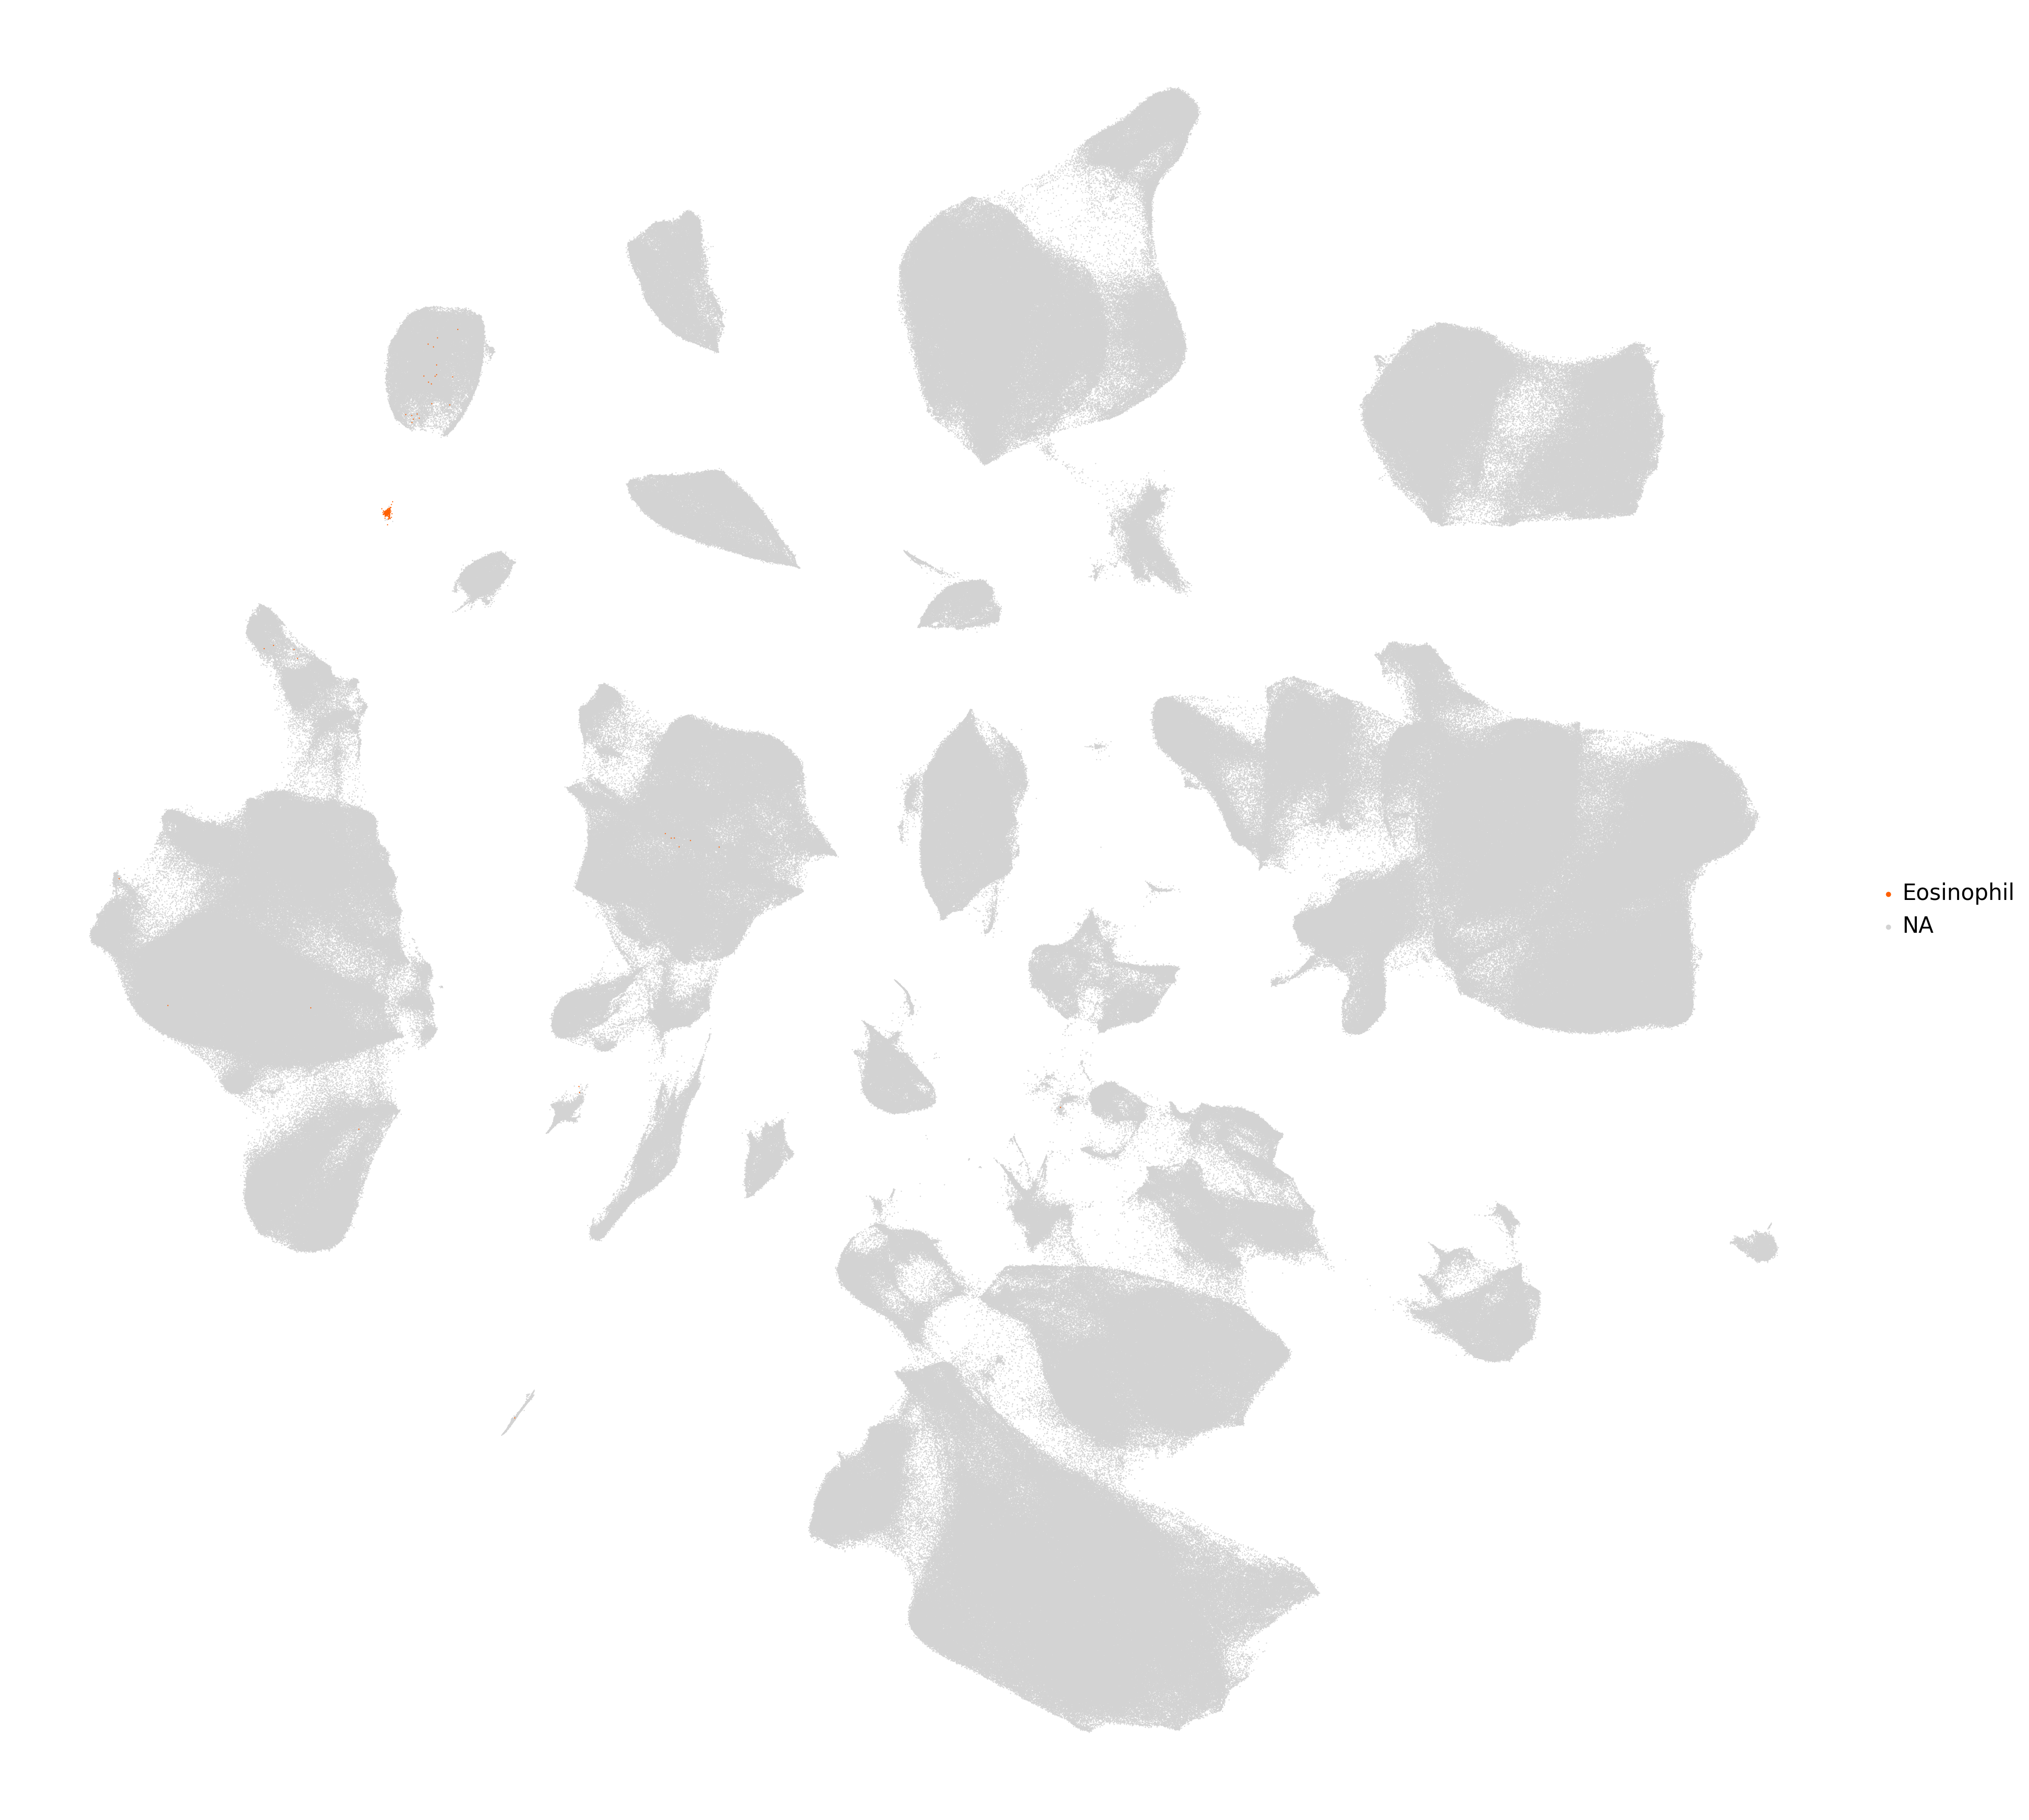

In [52]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(45,45))

sc.pl.umap(
    adata,
    color='final4',
    show=True,
    frameon=False,
    #legend_loc= "on data",
    legend_fontsize=30,
    s=10,
    title='',
    legend_fontoutline=2,
    vmax=60,
    palette=colors,
    groups="Eosinophil",
    save="eosinophil_pandisease_umapall.pdf"
                   
   # save="supplementary_integration.pdf"
)



In [ ]:
1

In [5]:
adata_i=adata[(adata.obs["final4"]=="Eosinophil")|
              (adata.obs["final4"]=="Mast cell")|
                (adata.obs["final4"]=="Neutrophil")
             
             
             ].copy()


ValueError: could not convert integer scalar

In [ ]:
sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)



In [ ]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"],
        "oesophageal": [
    "CCR3",
    "HRH4",
    "SUCNR1",
    "VSTM1",
    "CEBPE",
    "OLIG1",
    "OLIG2",
    "PRSS33",
    "CLC", "CCL2"
]
            }


sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="final4",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


In [ ]:
PRENATAL_GENES = {"BASOPHIL ONLY": ["PADI4", "NCF2", "TRMP6", "ITGB7", "CCR3",
                                   "NLRC5", "VSTM1"
                                   ]
                    "BASOPHIL MOSTLY": ["NCF1", "IL3RA", "S100P",
                                       "CR1", "MYO1F", "SULF2", 
                                       ],
                  "EOS": ["CALCRL", "IL13", "CXCL2", "CEMIP2", "HELLS", "CREG1", 
                         "IL4", "CD7", "BCL21L2"
                         ],
                  "ME":["IL3RA", "IL5RA"]
                         
    
}
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PRENATAL_GENES,
              groupby="final4",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


In [ ]:
genes_dict = {
    "PRENATALSKIN": ["PRG2", "IL5RA", "IL3RA"],
    "Gonzalo": [
    "CPA3",
    "HDC",
    "CLC",
    "FCER1A",
    "IL3RA",
    "SLC45A3",
    "IL5RA",
    "HRH4",
    "PRG2",
    "FUT4",
    "CD34",
],
}

sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              genes_dict,
              groupby="final4",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 


In [ ]:
# adata.obs["xeniummap"] = adata.obs["final17"].where(
#     adata.obs["tech"] == "scrna",  # keep final17 only if tech is scrna
#     other="new"                     # otherwise set "new"
# )

# # Optional: make categorical
# adata.obs["xeniummap"] = adata.obs["xeniummap"].astype("category")

In [3]:
1

1

In [78]:
adata_i.obs.dataset_id.value_counts()

dataset_id
bullouspemphigoid          1359
Rojahn_AD                    17
Ganier_BCC                    9
bcc_scc_yost                  7
gudjonsson_regional           6
Reynolds                      6
Luc_Psoriasis                 6
HS_Mariottoni                 5
Lichen planus_GSE254542       4
SCCarcinoma_Ji                4
ning_wound                    4
Greenleaf_AA                  4
HS_Moran                      3
Sarcoidosis_Damsky            3
AA_Greenleaf                  3
Keloid_Deng                   3
Mariottoni_HS                 2
Ji_SCCarcinoma                2
Bangert_AD                    2
Fiskin_AD                     2
AA_NY_GSE233906               1
Lyme_jiang                    1
Ma_Prurigo                    1
GA_Wang                       1
Dobie_Dupuytren               1
Sole-Boldo                    1
Direder_Keloid                1
bcc_yerly                     1
Acne_Do                       1
Name: count, dtype: int64

In [4]:
adata_i=adata[adata.obs["final4"]=="Eosinophil"].copy()


In [19]:
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(45,45))


/tmp/ipykernel_3862003/1752277132.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


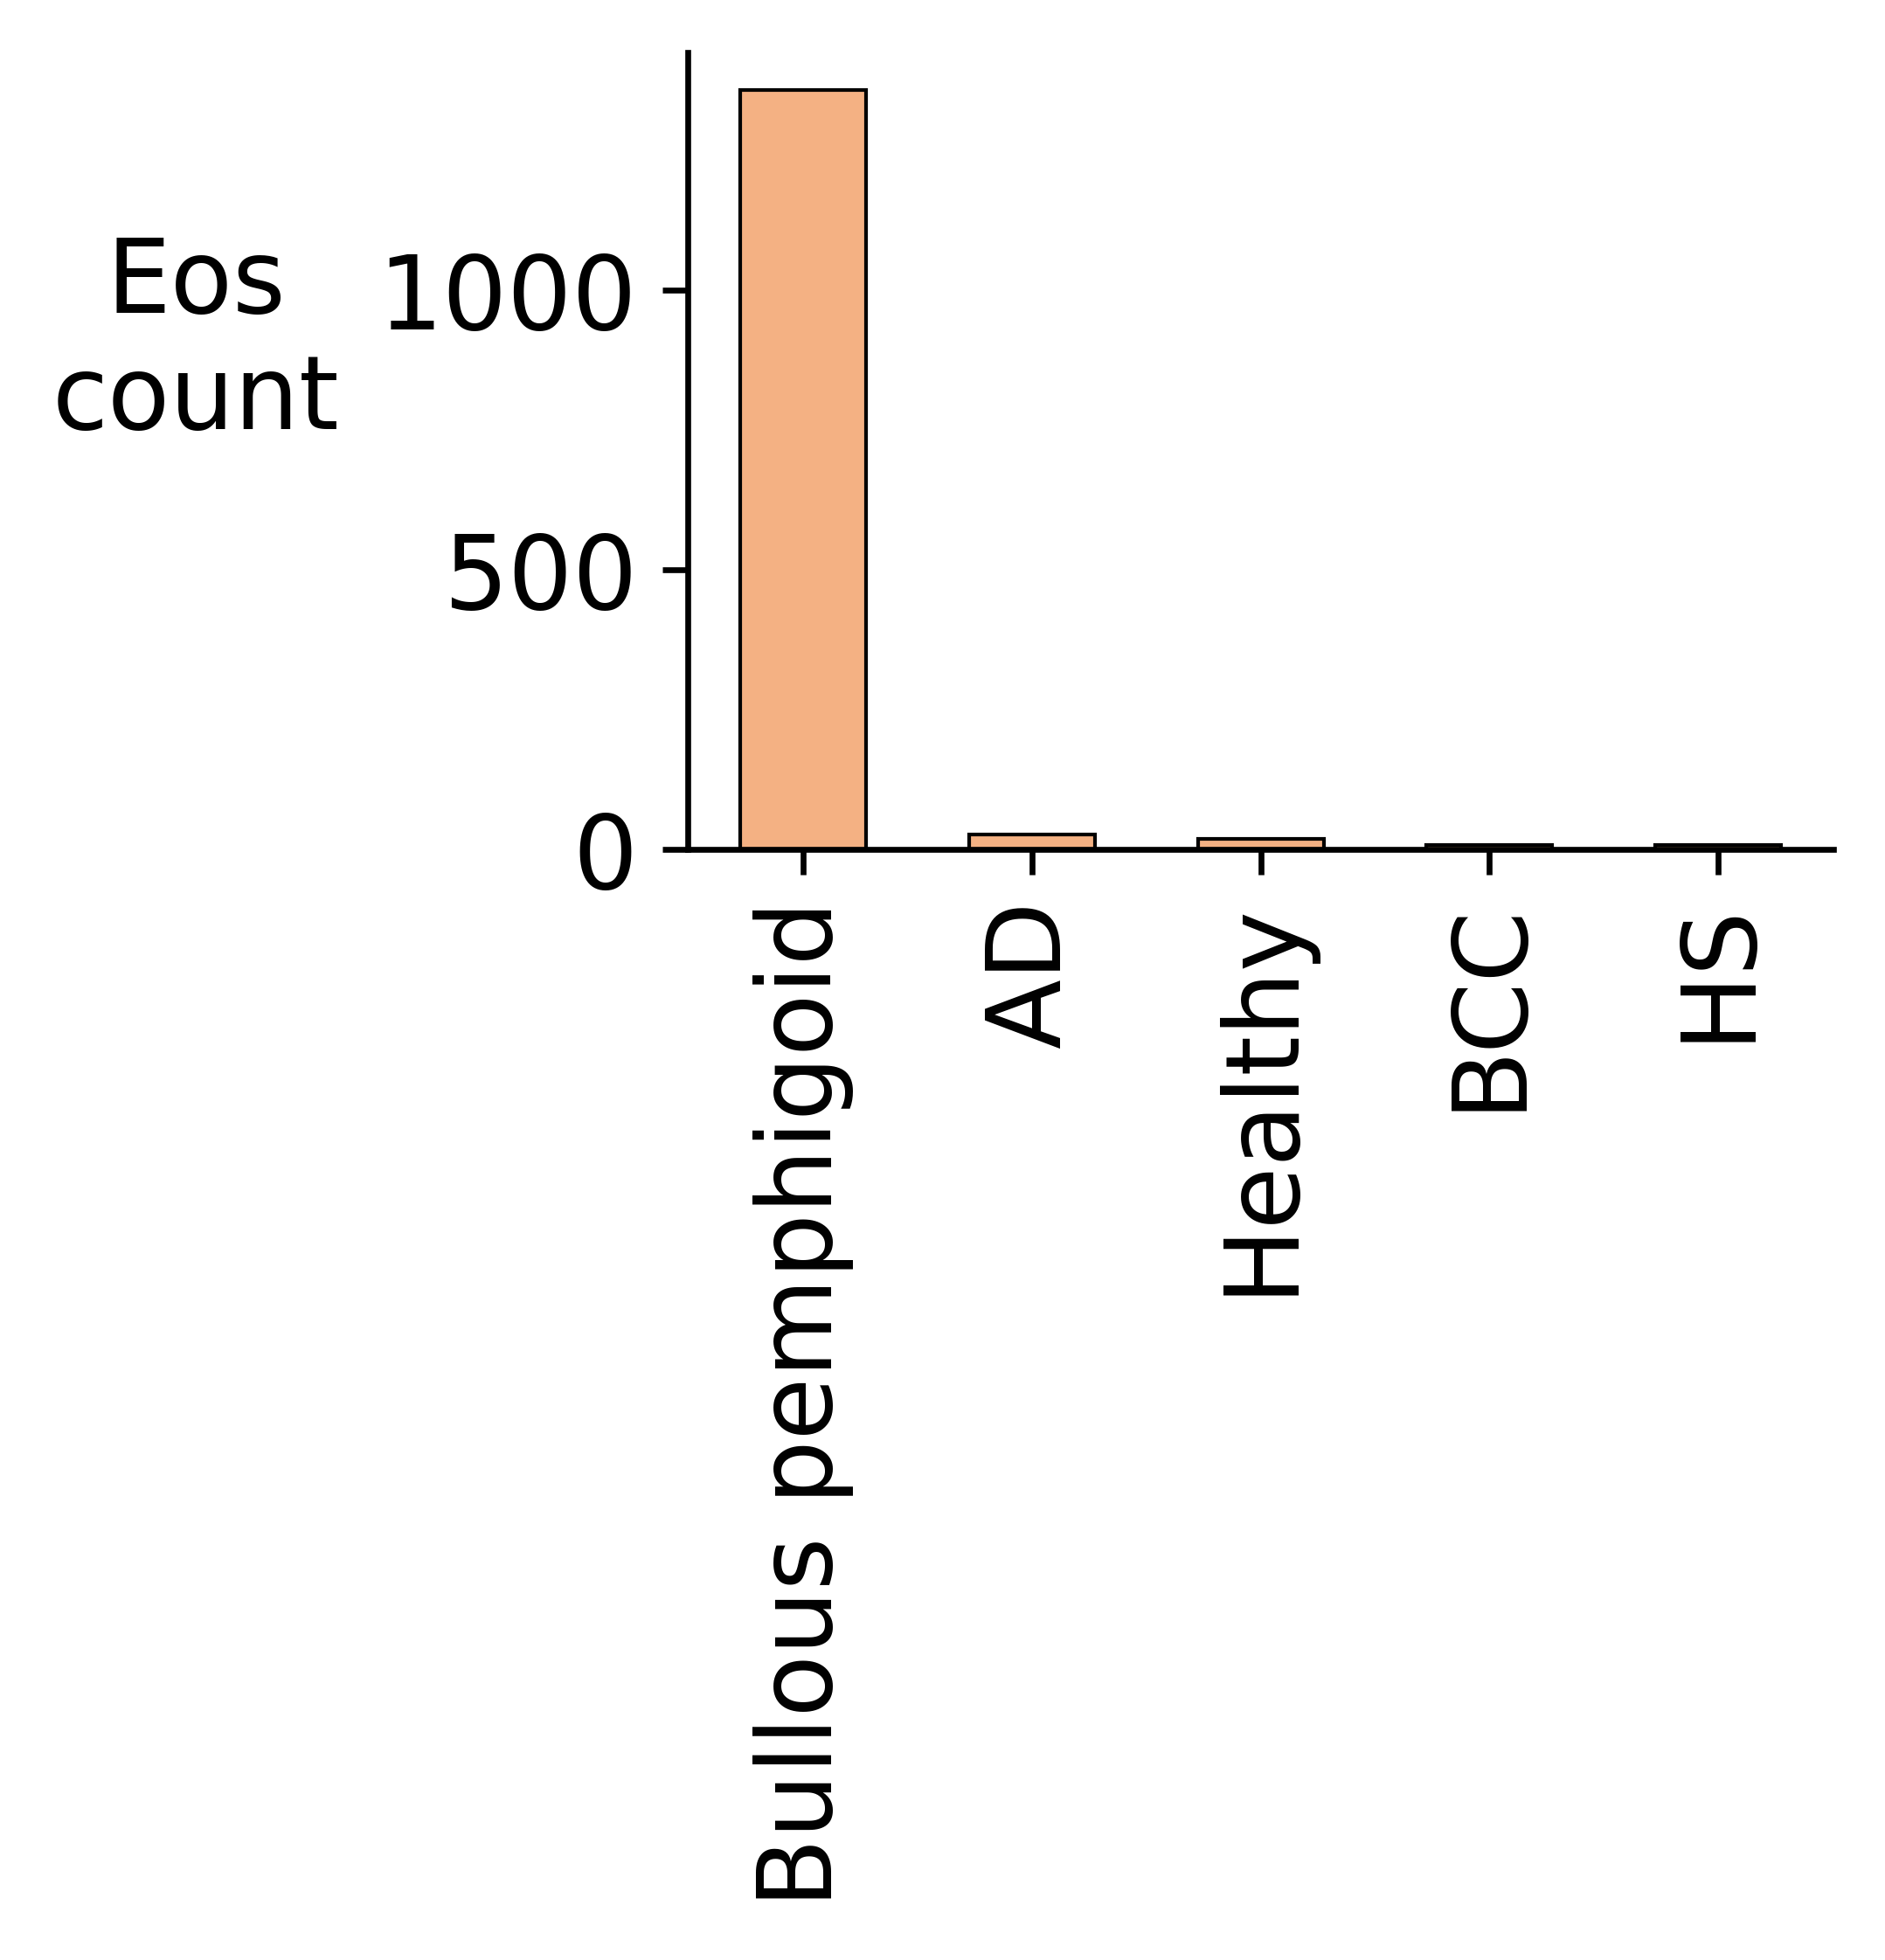

In [47]:
import matplotlib.pyplot as plt

counts = (
    adata_i.obs["Patient_status"]
    .value_counts()
    .head(5)
    .sort_values(ascending=False)
)

plt.figure(figsize=(2.8, 2.0))

plt.bar(
    counts.index,
    counts.values,
    width=0.55,
    color="#F4B183",
    edgecolor="black",
    linewidth=0.5
)

ax = plt.gca()

# remove background grid explicitly
ax.grid(False)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=90)

# horizontal ylabel
plt.ylabel("Eos\ncount", rotation=0, labelpad=25)

plt.xlabel("")
plt.tight_layout()
plt.show()

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


neighbours done
start umap


/tmp/ipykernel_3862003/290952958.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_i, resolution=2, key_added='leiden_res2', neighbors_key="neighbor_20")


KeyError: 'Could not find key leiden_res0.3 in .var_names or .obs.columns.'

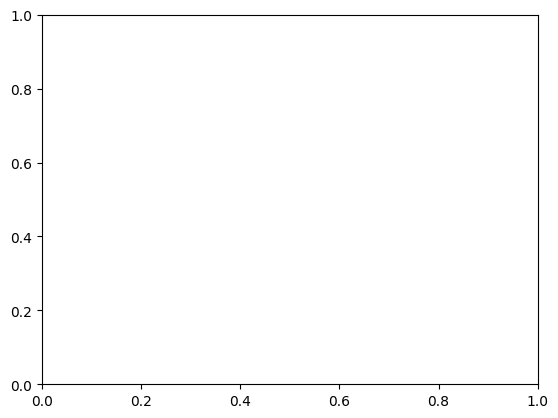

In [7]:
sc.pp.neighbors(adata_i, use_rep = 'X_scanvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 
sc.tl.leiden(adata_i, resolution=2, key_added='leiden_res2', neighbors_key="neighbor_20")

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res0.3',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

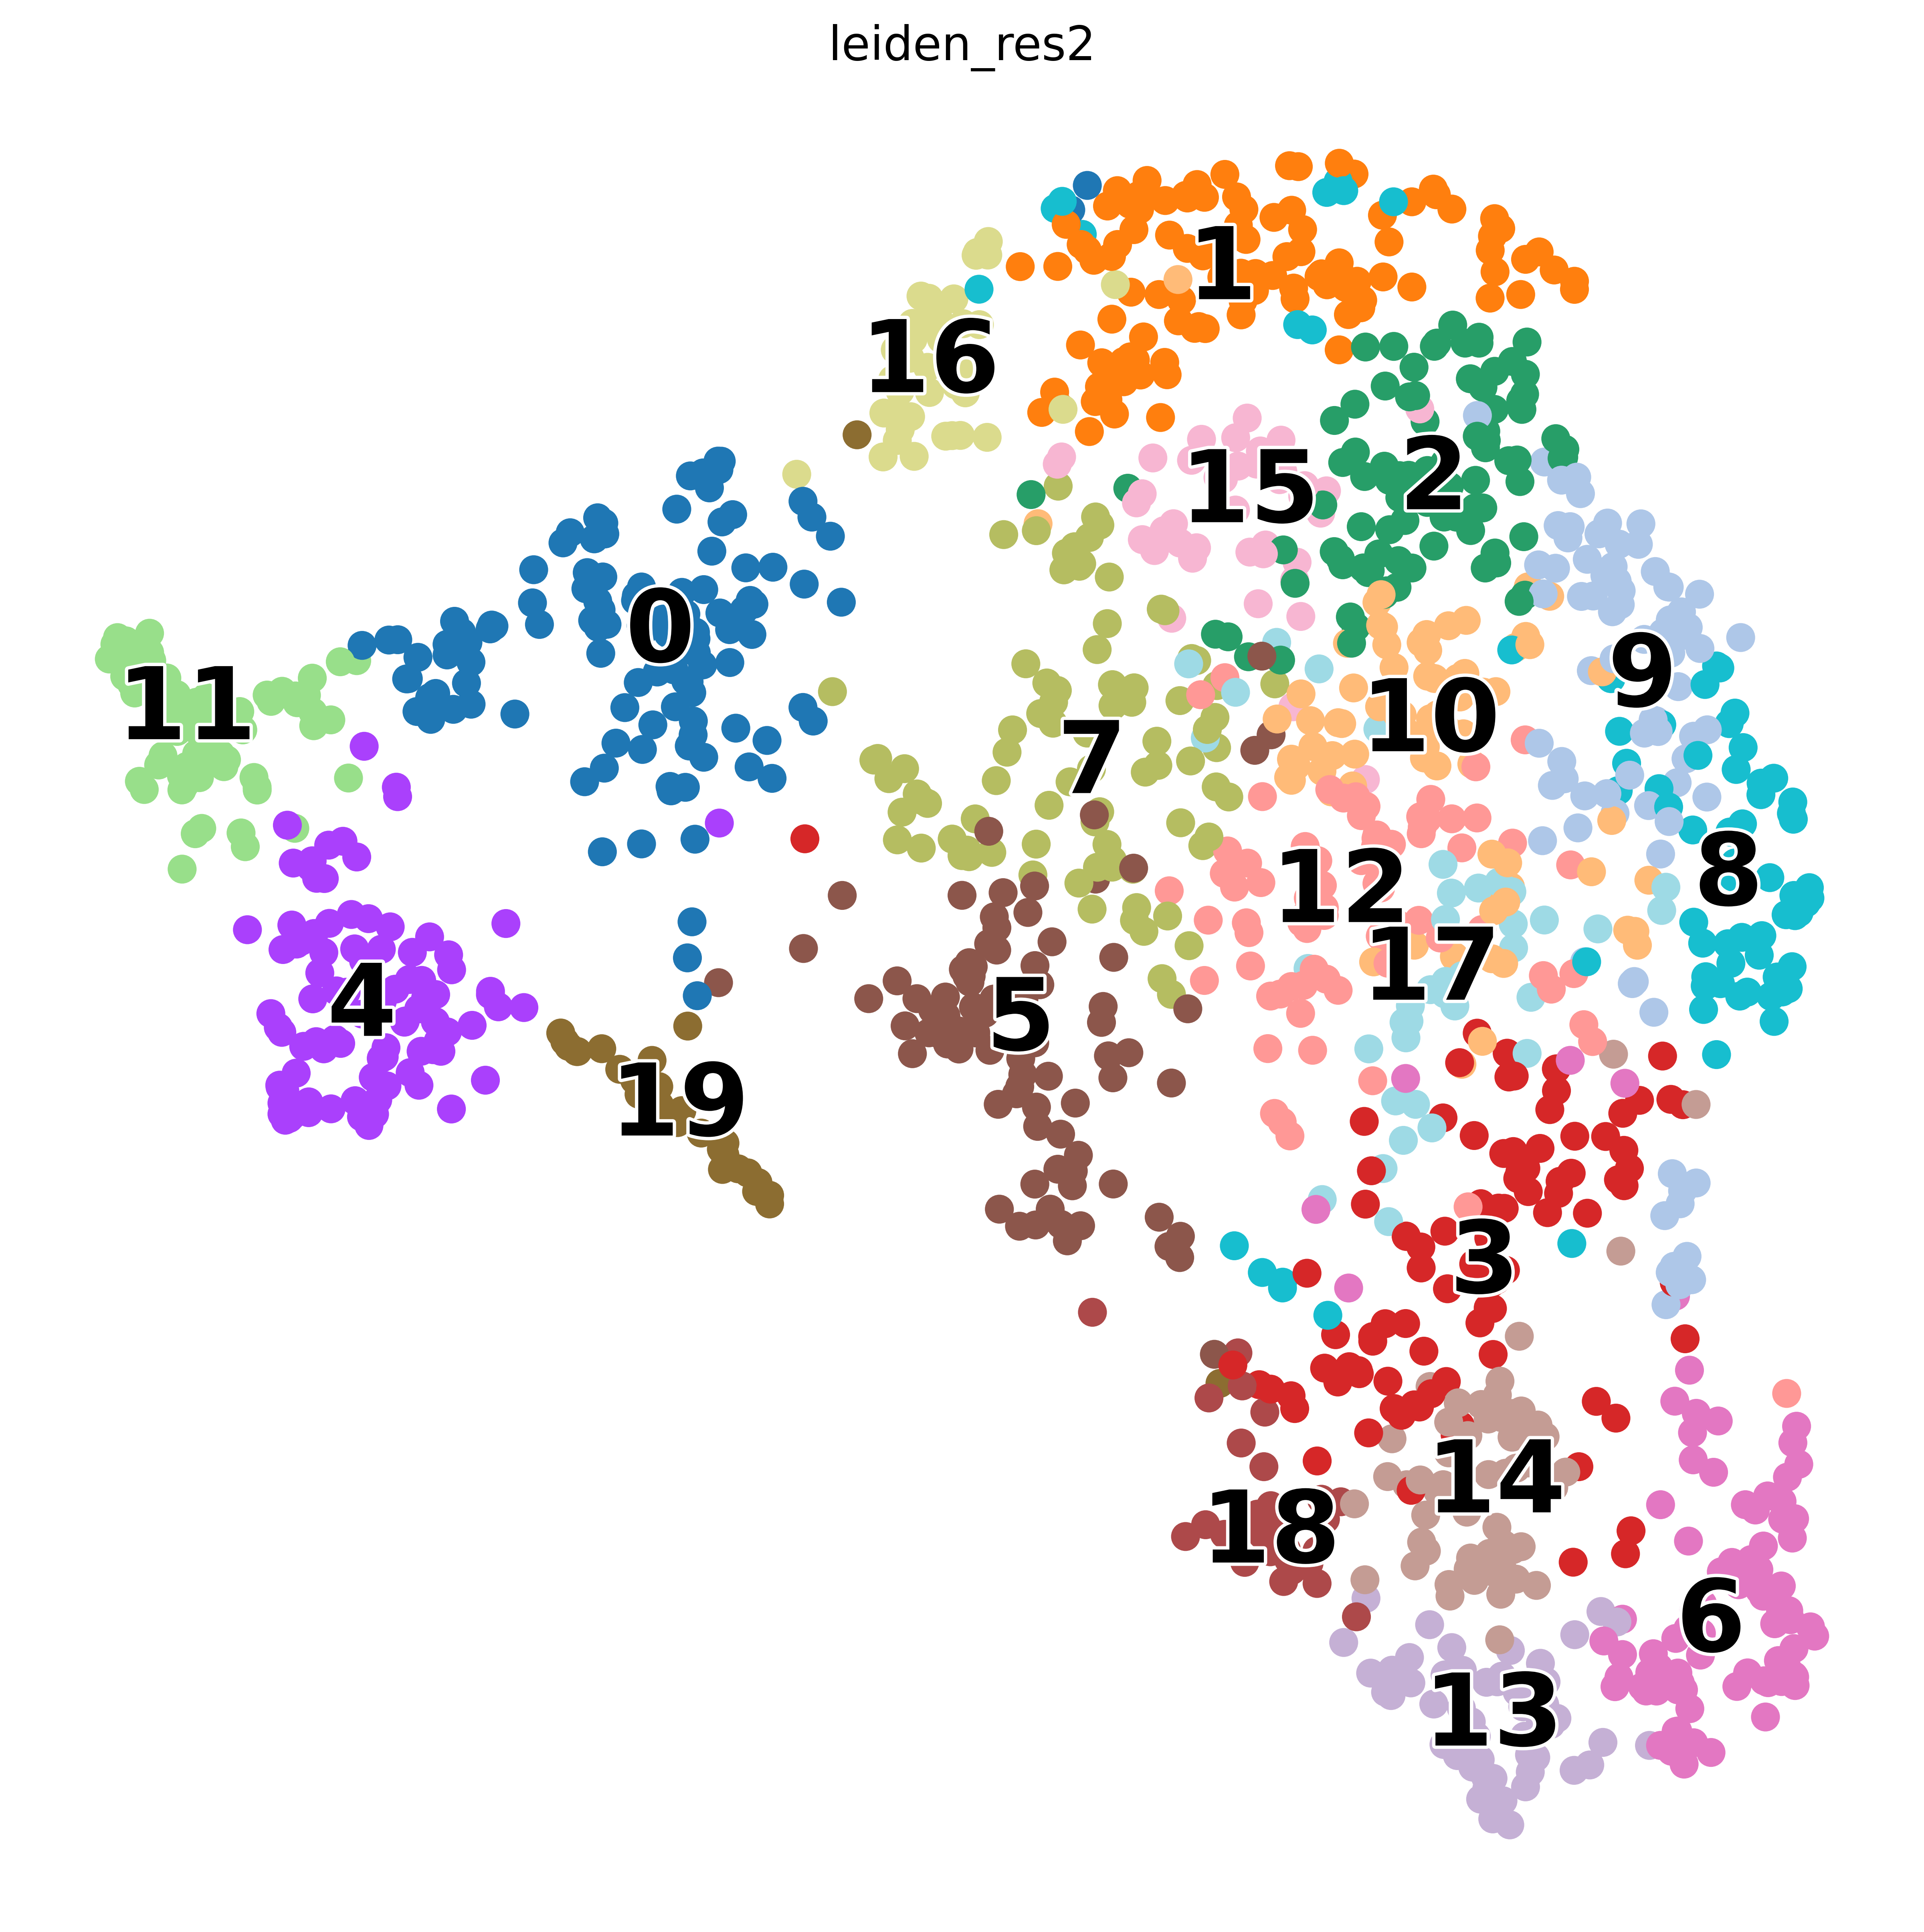

In [36]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(10,10))

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res2',
    ],
    legend_loc="on data",
    s=300, 
    legend_fontoutline=2,
    legend_fontsize=30
)

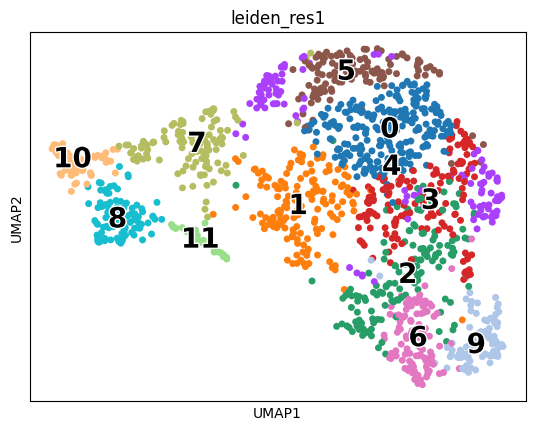

In [9]:
sc.tl.leiden(adata_i, resolution=1, key_added='leiden_res1', neighbors_key="neighbor_20")

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res1',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [12]:

sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)

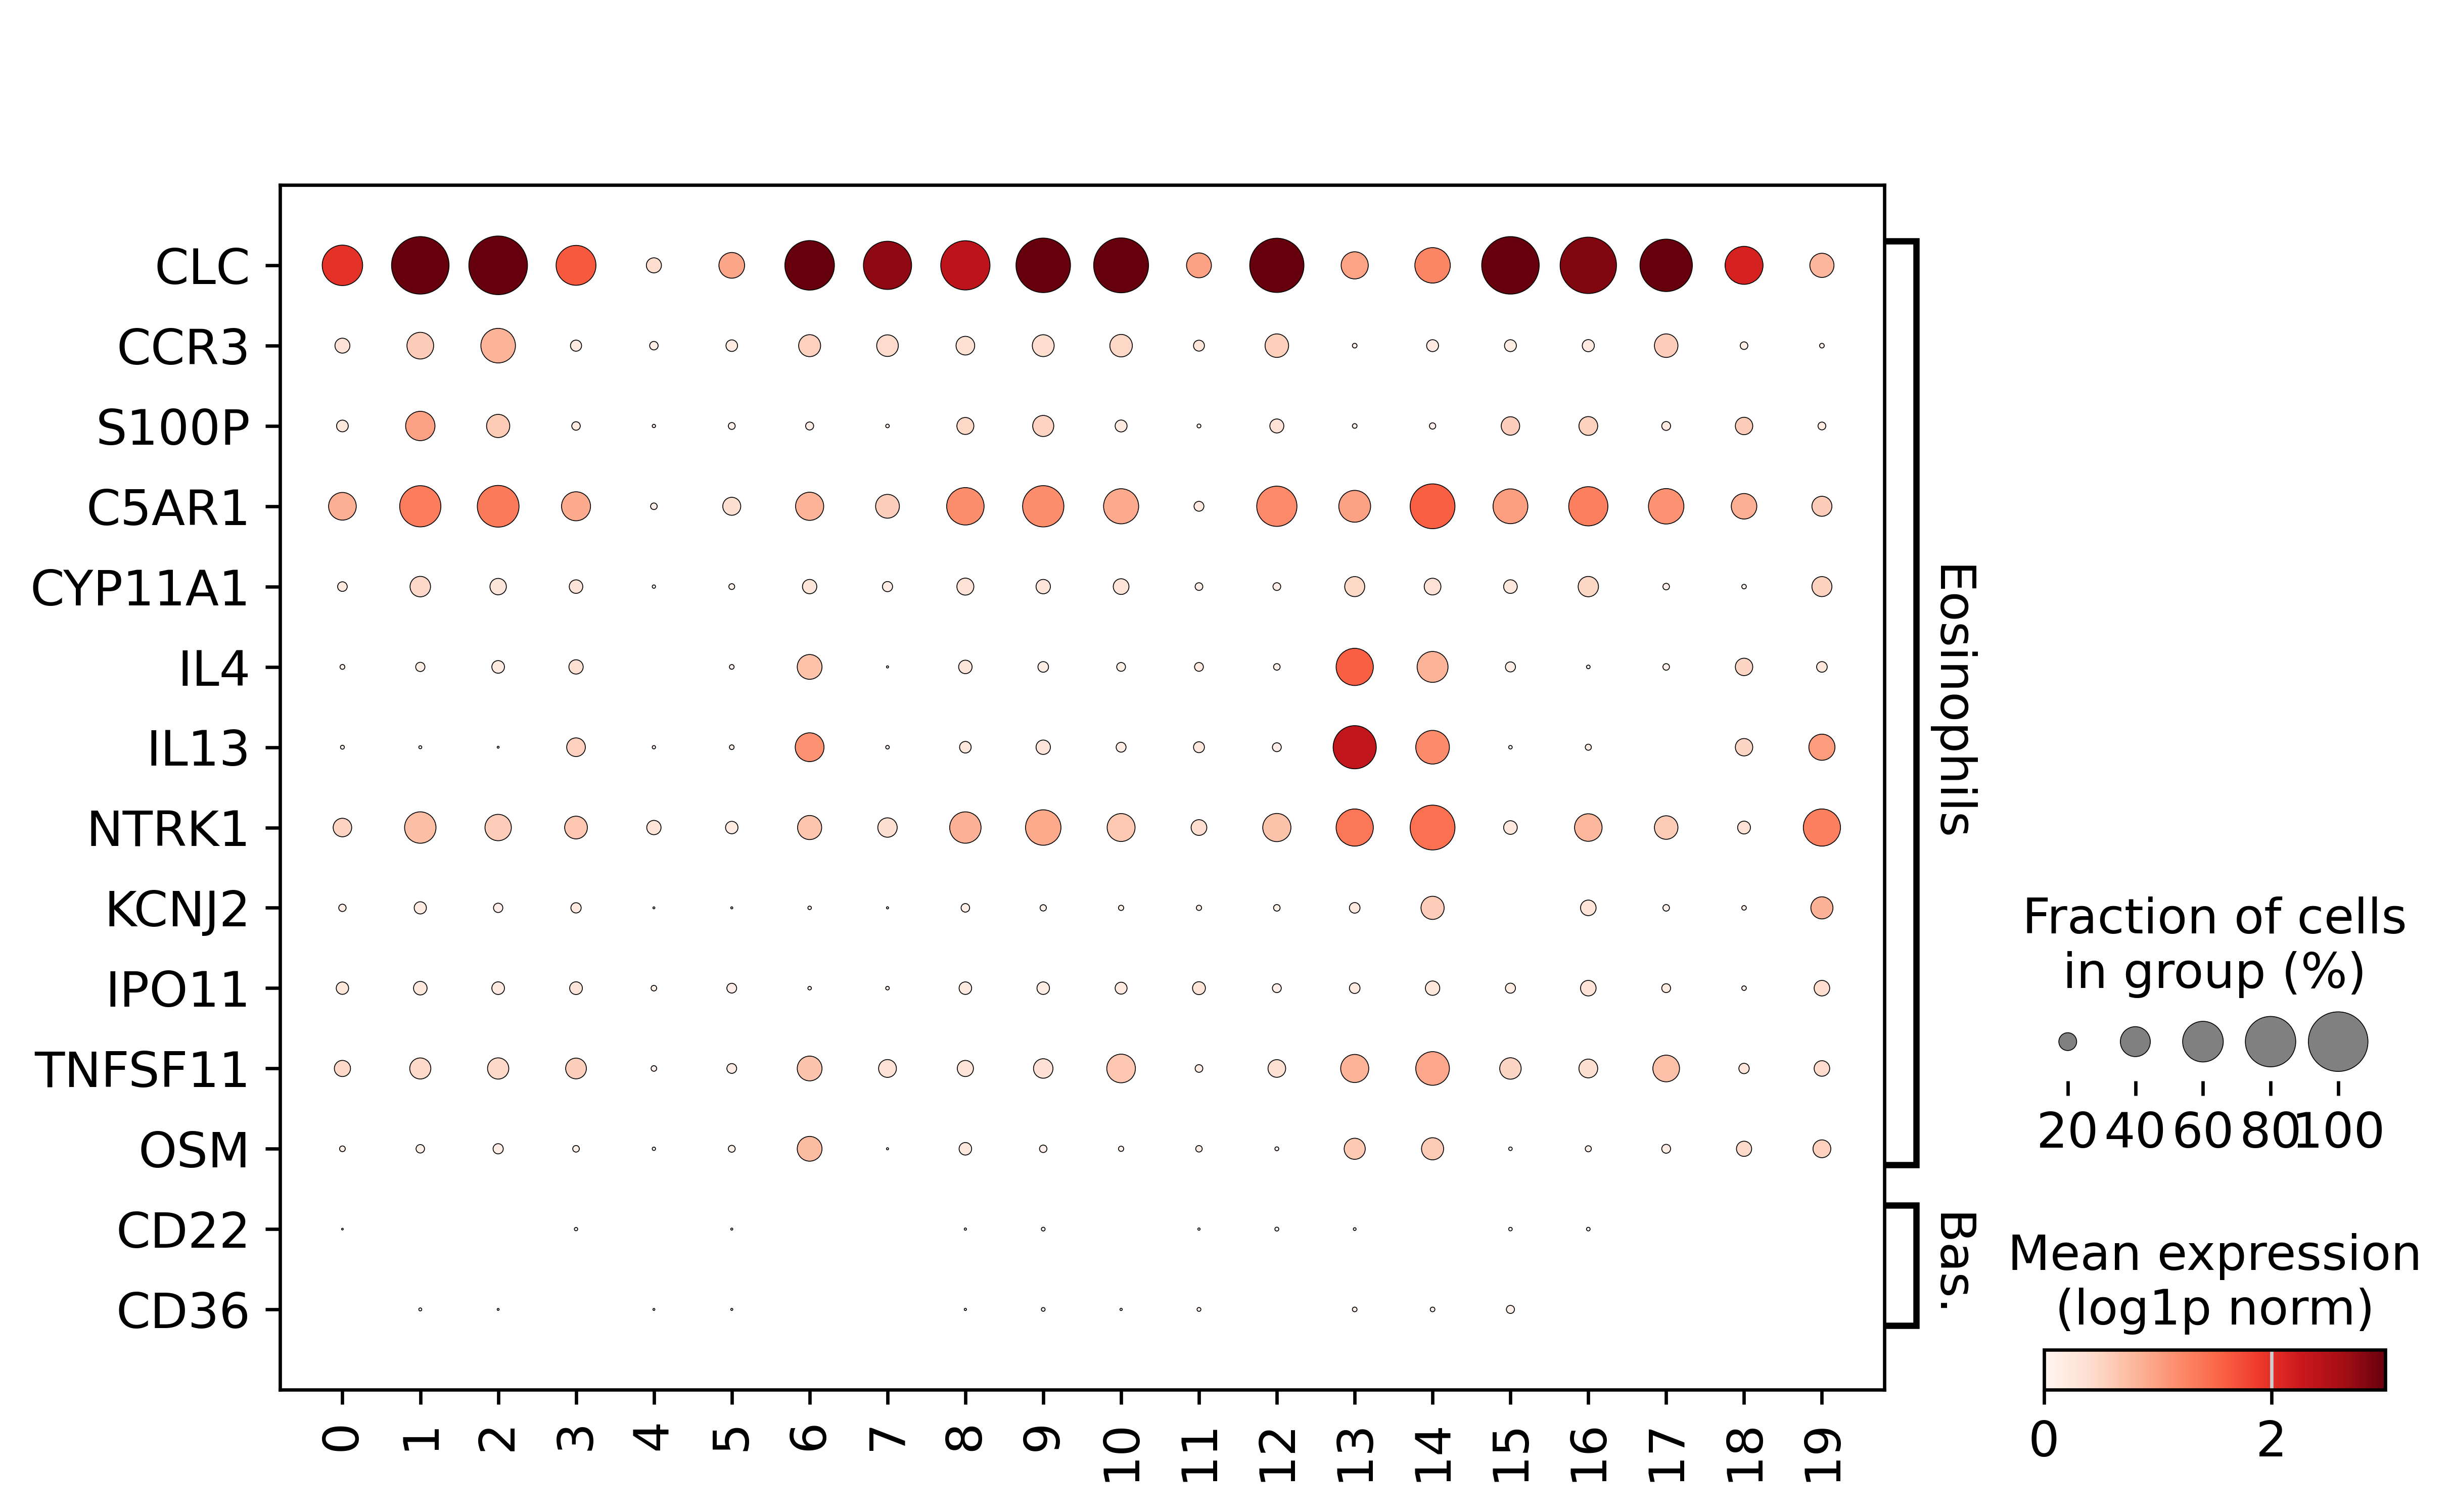

In [51]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(10,10))

PLOT = {   "Eosinophils": [  "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13", "ALOX5",
    "ETS1",
   # "KLF5",
   # "NTRK1",
   # "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM", "IKZF1",
    "CD69",
     
    "CORO1A",
   
    "NR4A1",
   
    "IL3RA","MBP"
                    
    
    
    
#     "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
#                             "S100P", "C5AR1",    "CYP11A1", 
#                              "IL4",
#     "IL13",
#     "NTRK1",
#     "KCNJ2",
#     "IPO11",

#     "TNFSF11",
#     "OSM"
                           ],
        "Basophil": [#"MCPT8", 
     "CD22", "CD36",# "CD40LG", "FCGR2B",
               #  "ENPP3"
            
             'CD40LG', 'FCGR1B', 'FCGR3A', 'FCGR2B', 'CXCR1', 'CXCR2'
            
                 ],
    # "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    # "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    # "PTJER": ["AOC1", "LTC4S", "FCER1A"],
    #   "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
    #     "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
    #     "paper": ["EPX",  "CD200R1"]
            }
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res2",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(log1p norm)",
              vmax=3,
             swap_axes=True,
             #   dot_max=.3,
             )

 

In [49]:
# PLOT = {   "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
#                             "S100P", "C5AR1",    "CYP11A1", 
#                              "IL4",
#     "IL13",
#     "ETS1",
#     "KLF5",
#     "NTRK1",
#     "KCNJ2",
#     "IPO11",

#     "TNFSF11",
#     "OSM"
#                            ],
#         "Basophil": [#"MCPT8", 
#      "CD22", "CD36",# "CD40LG", "FCGR2B",
#                #  "ENPP3"
#                  ],
#     # "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
#     # "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
#     # "PTJER": ["AOC1", "LTC4S", "FCER1A"],
#     #   "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
#     #     "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
#     #     "paper": ["EPX",  "CD200R1"]
#             }
# sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
#               PLOT,
#               groupby="final4",
#               dendrogram=False, 
#                # standard_scale="var",
#               colorbar_title="Mean expression\n(minmax norm)",
#              # swap_axes=True,
#              #   dot_max=.3,
#              )

 

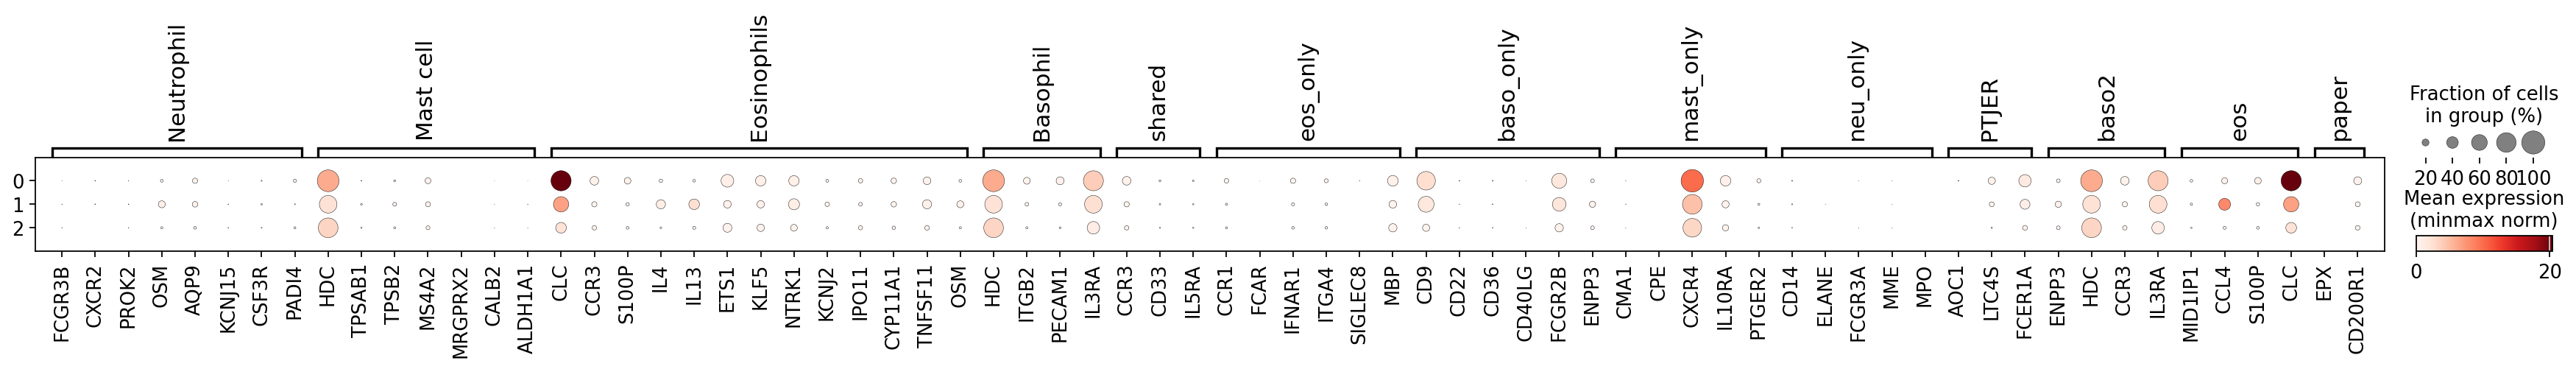

In [83]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"]
            }
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res0.3",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 

In [65]:
RENAME = {"1": "Basophil",
          "0": "Eosinophil",
          "2": "Eosinophil",
          "3": "Eosinophil",
         
         }
adata.obs["tmp"] = adata.obs["leiden_res1"].map(RENAME)

In [ ]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res0.3",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

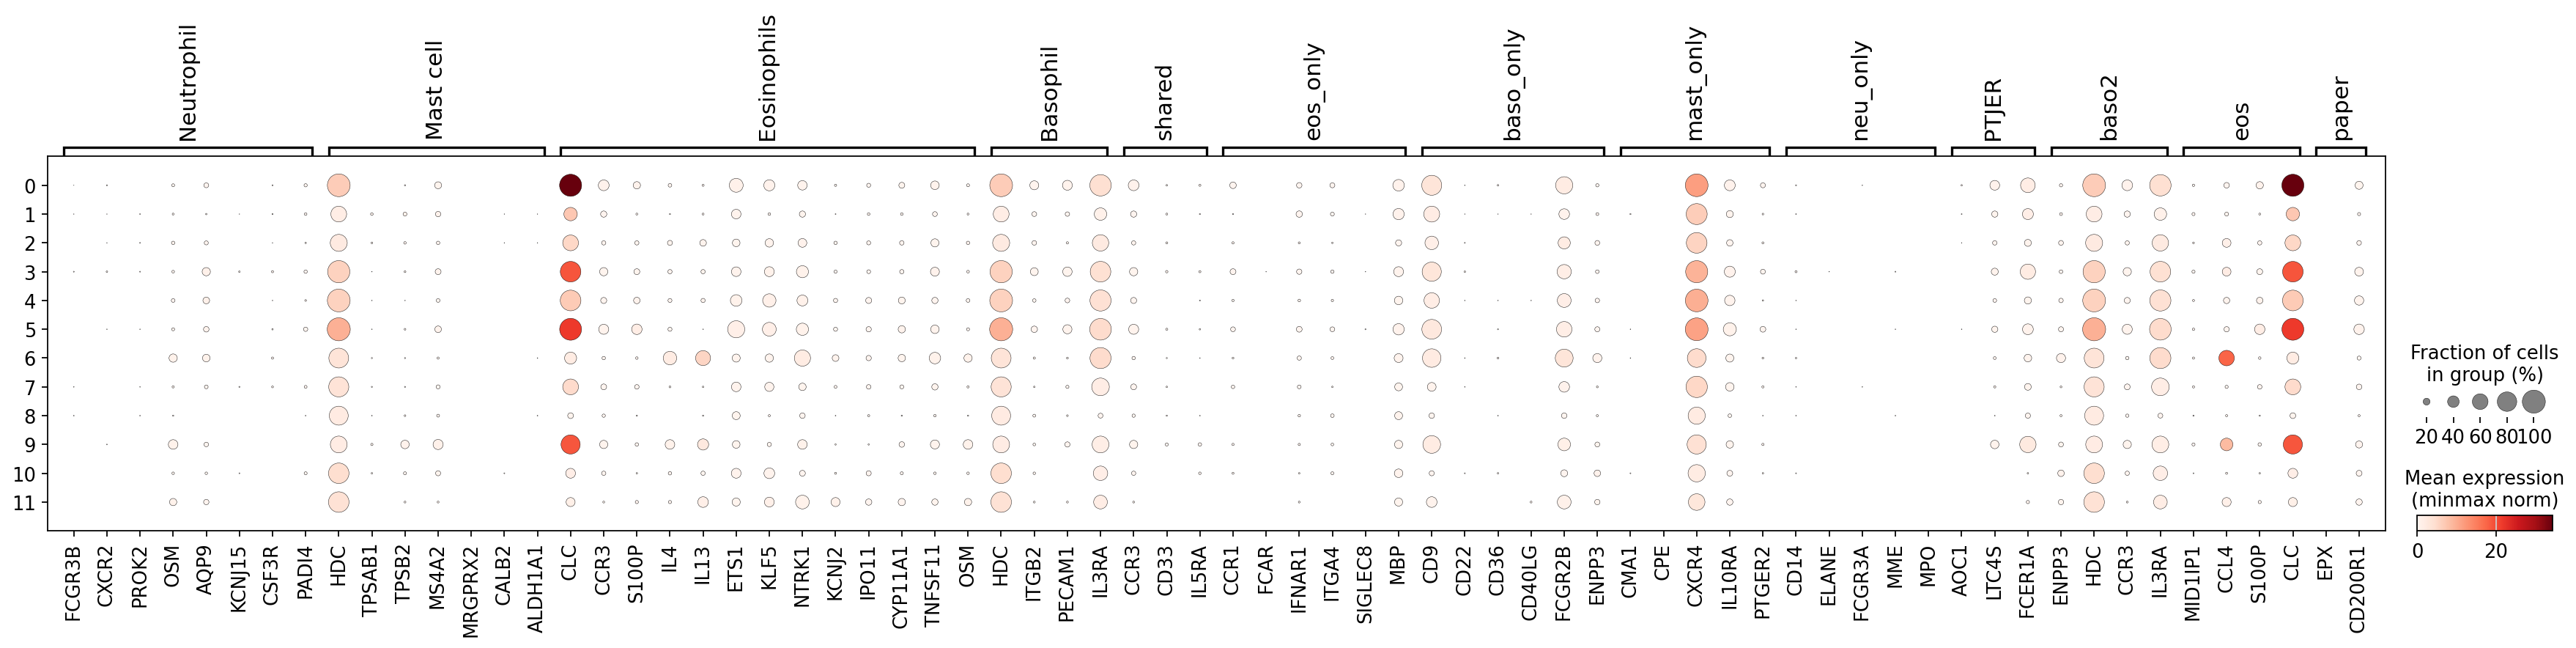

In [84]:
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res1",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

In [95]:
adata_i.obs.Patient_status.value_counts()

Patient_status
Bullous pemphigoid               1358
AD                                 27
Healthy                            18
BCC                                 8
HS                                  8
nan                                 6
SCC                                 6
Psoriasis                           6
AA                                  4
Lichen planus                       4
Sarcoidosis                         3
Keloid                              2
PWH27D7                             2
Granuloma annulare                  1
Lyme_disease/Erythema migrans       1
Non-keloid scar                     1
PWH26D1                             1
PWH28D7                             1
Prurigo                             1
Dupuytren                           1
Acne                                1
Name: count, dtype: int64

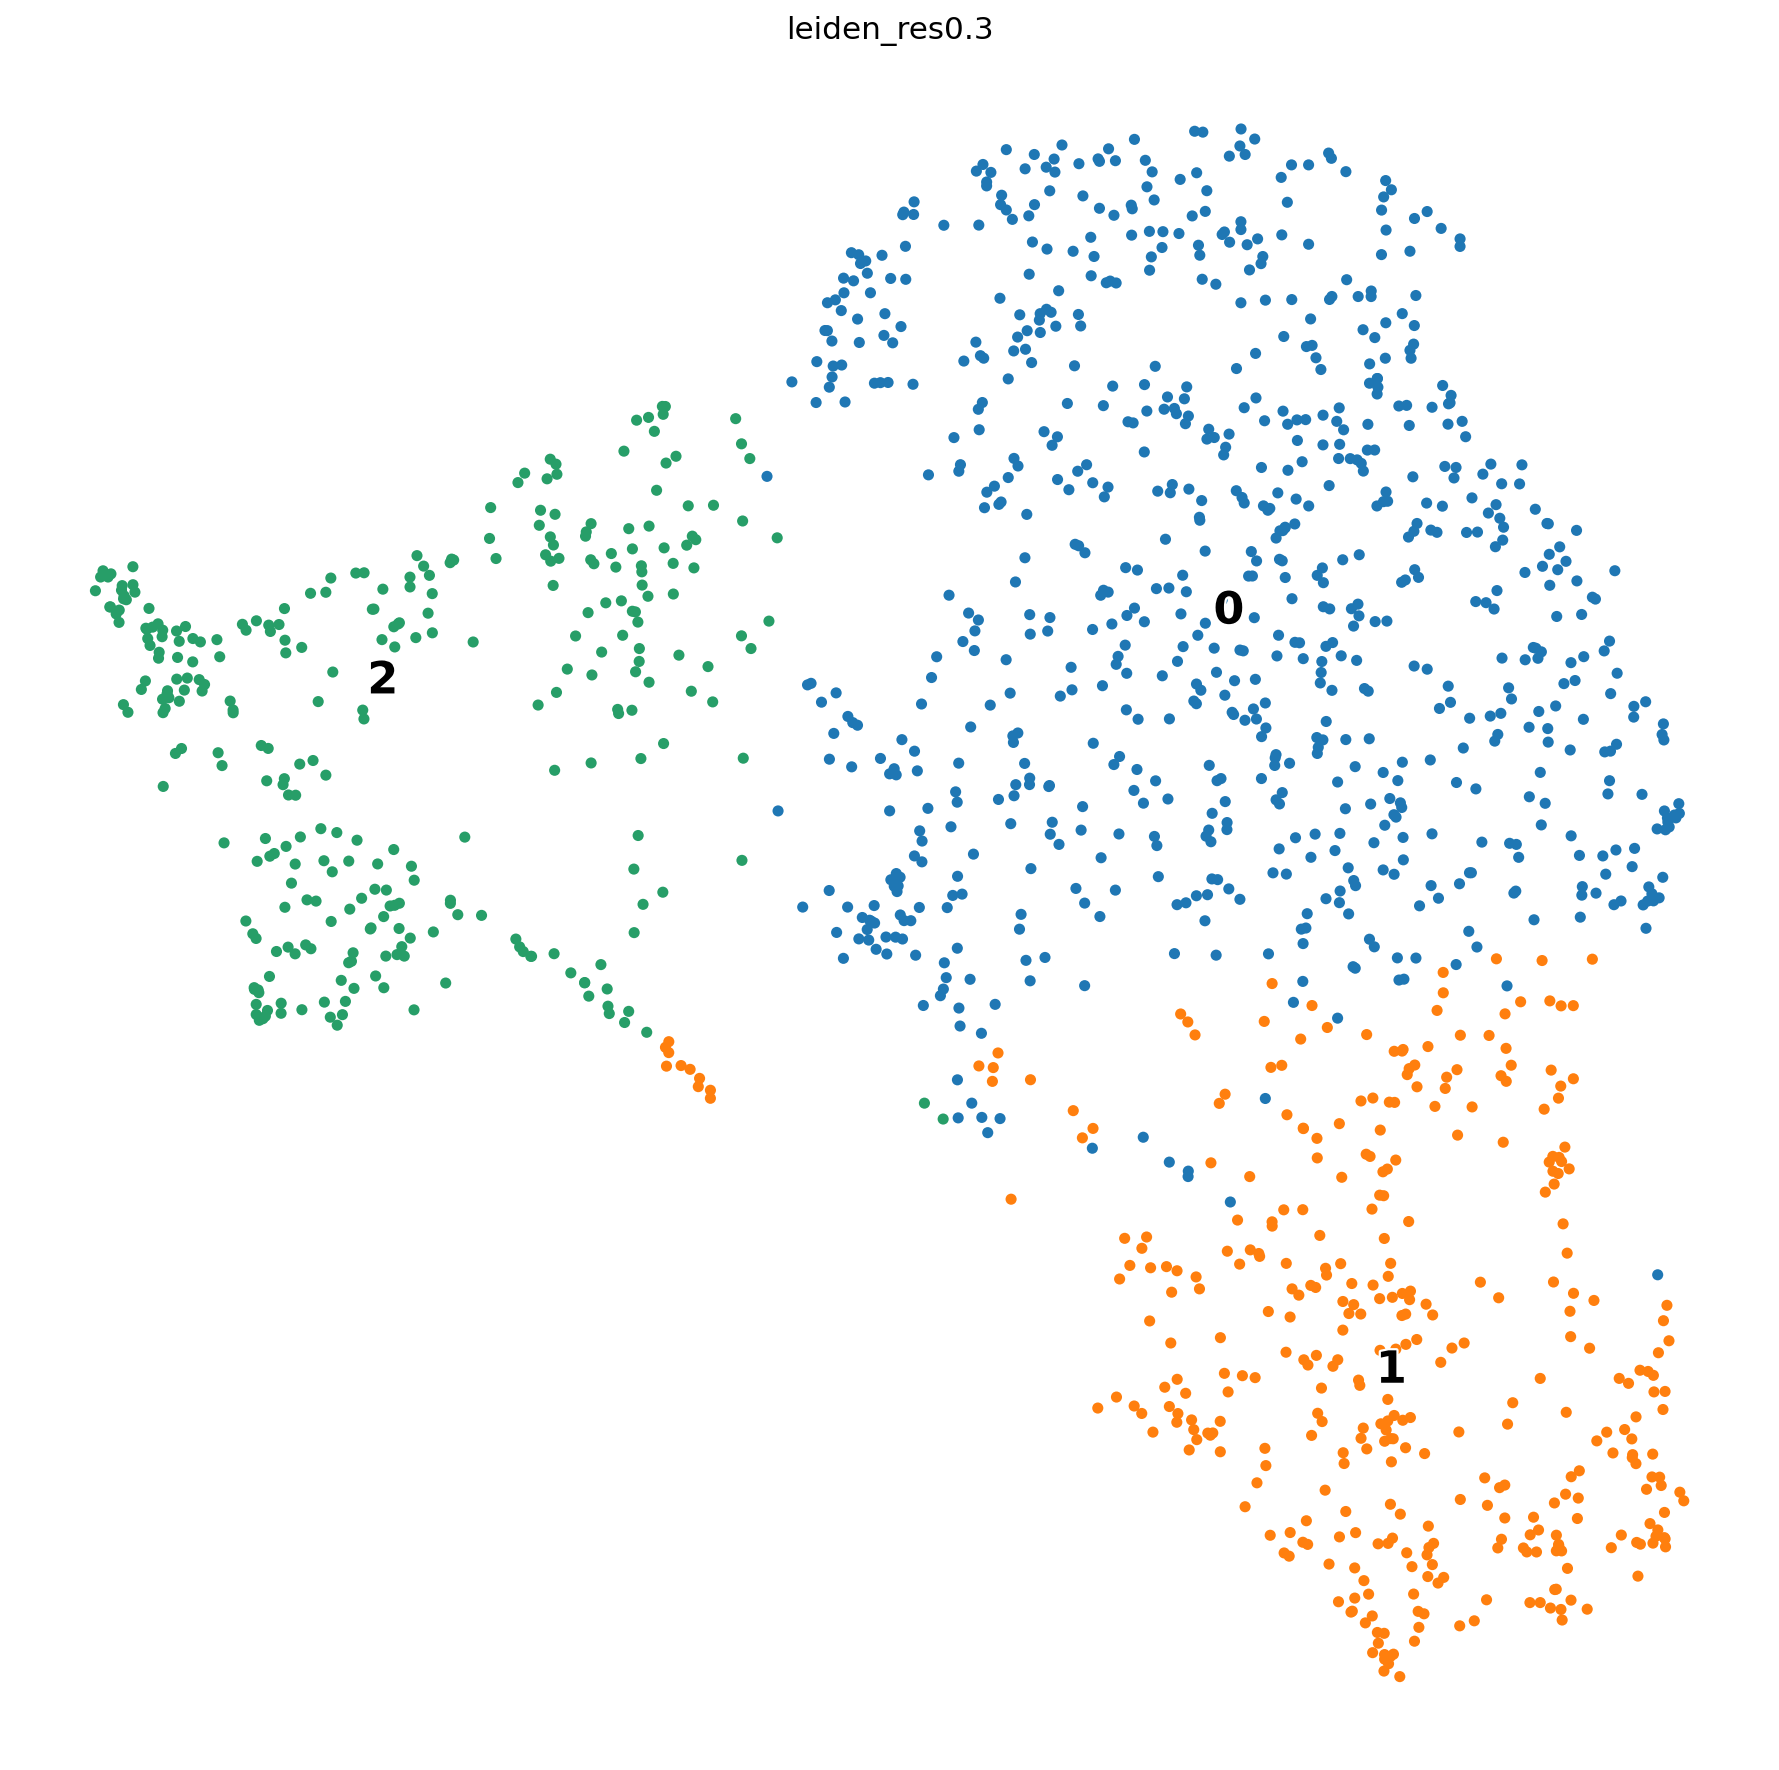

In [88]:
sc.tl.leiden(adata_i, resolution=2, key_added='leiden_res2', neighbors_key="neighbor_20")

sc.pl.umap(
    adata_i,
    color=[
      'leiden_res0.3',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

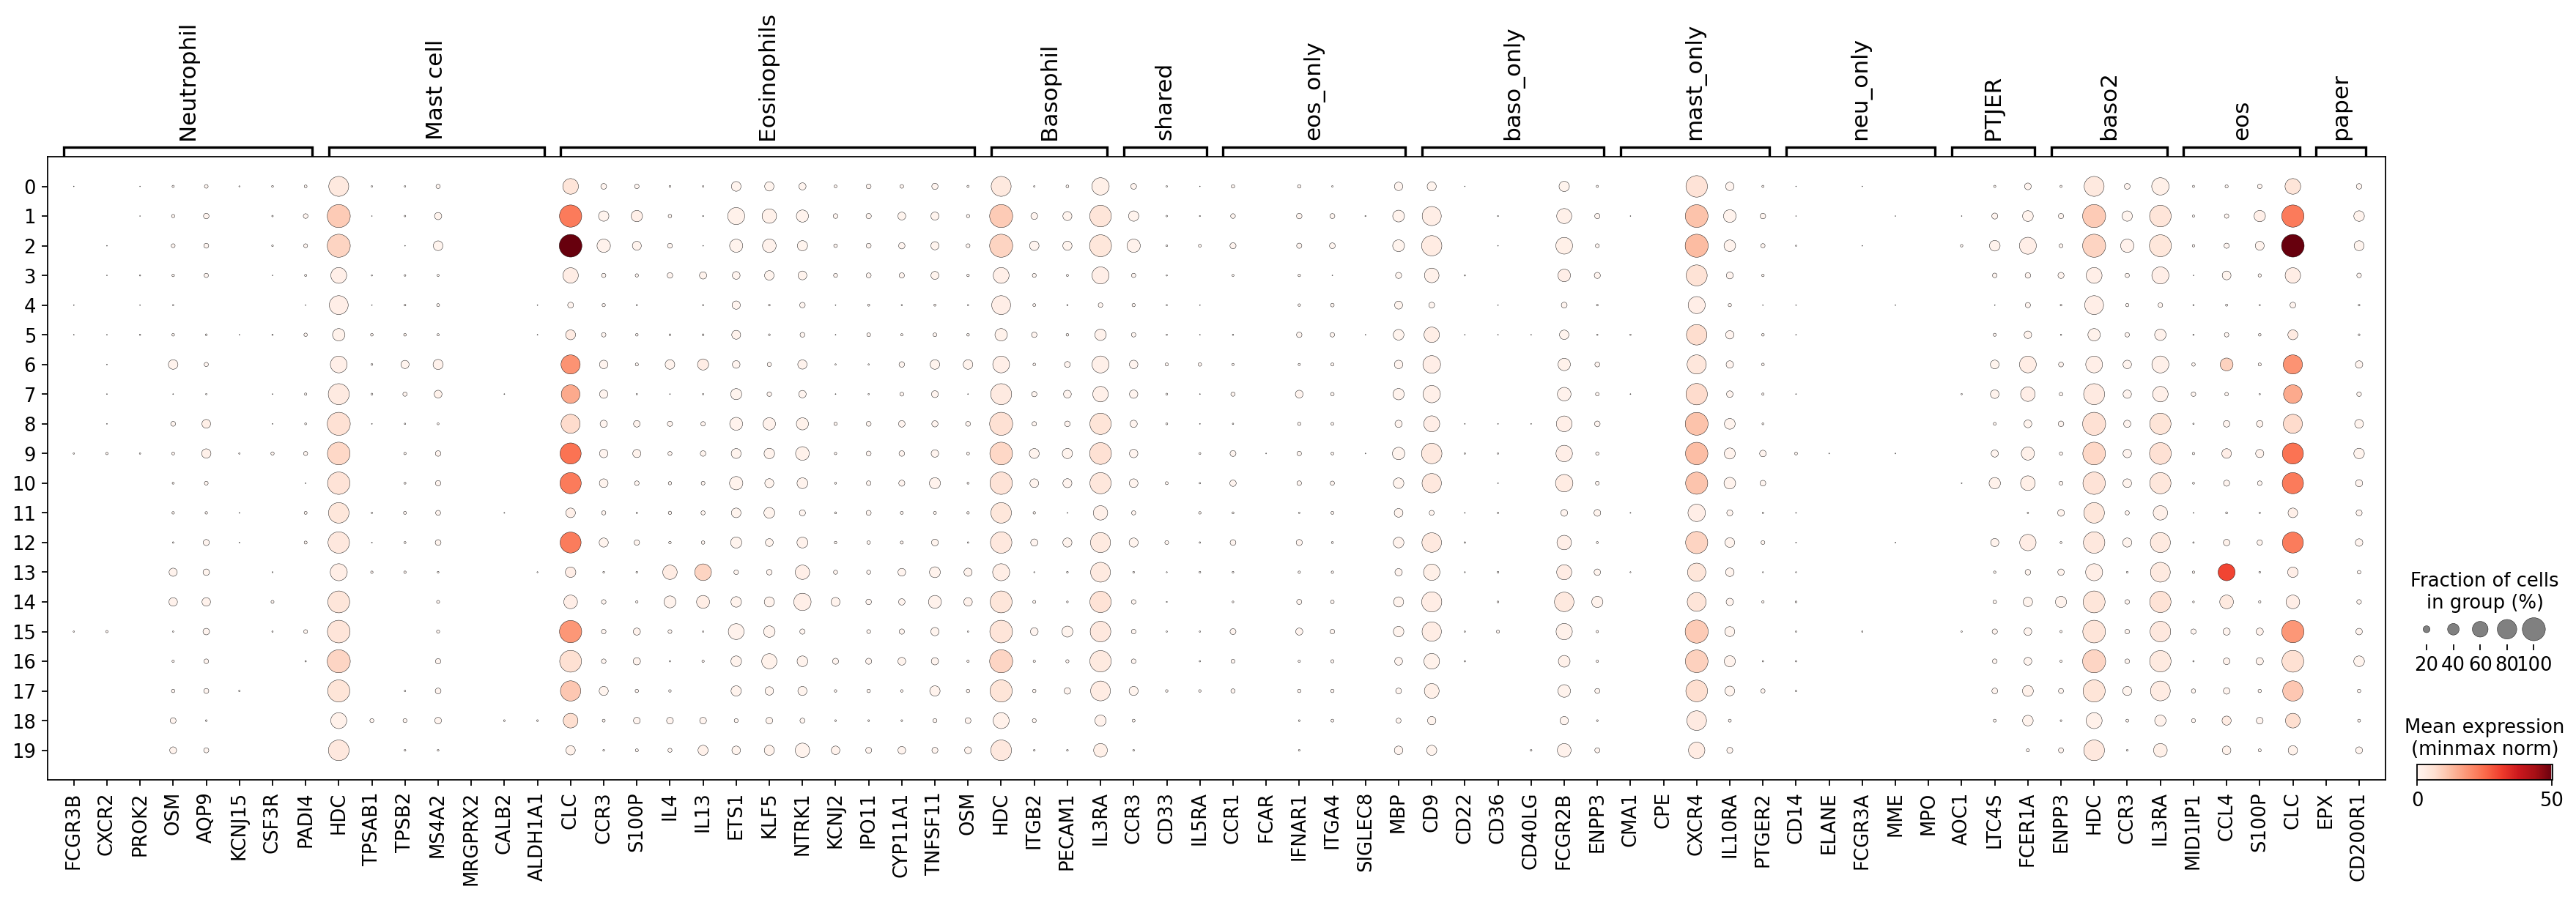

In [92]:
sc.pl.dotplot(adata_i,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res2",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

In [93]:
adata_i[adata_i.obs["leiden_res2"]=="13"].obs["Patient_status"].value_counts()

Patient_status
Bullous pemphigoid    54
AD                     4
PWH27D7                2
Name: count, dtype: int64

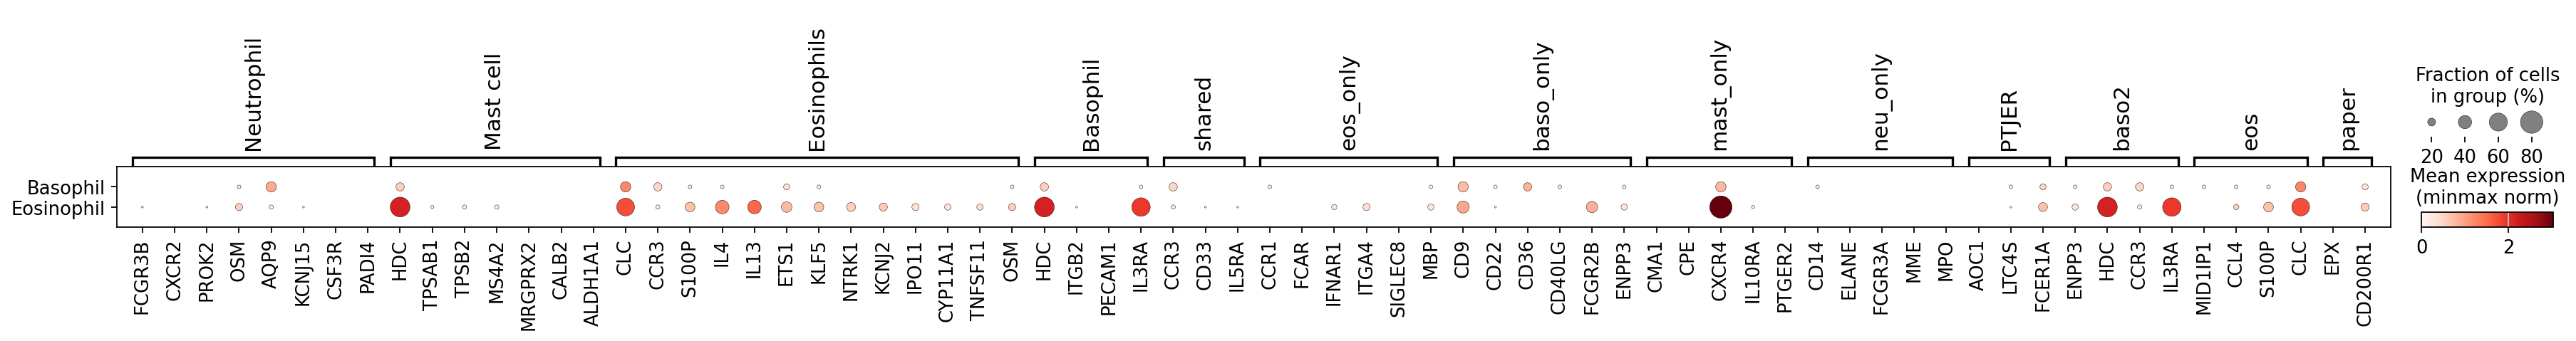

In [66]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="tmp",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

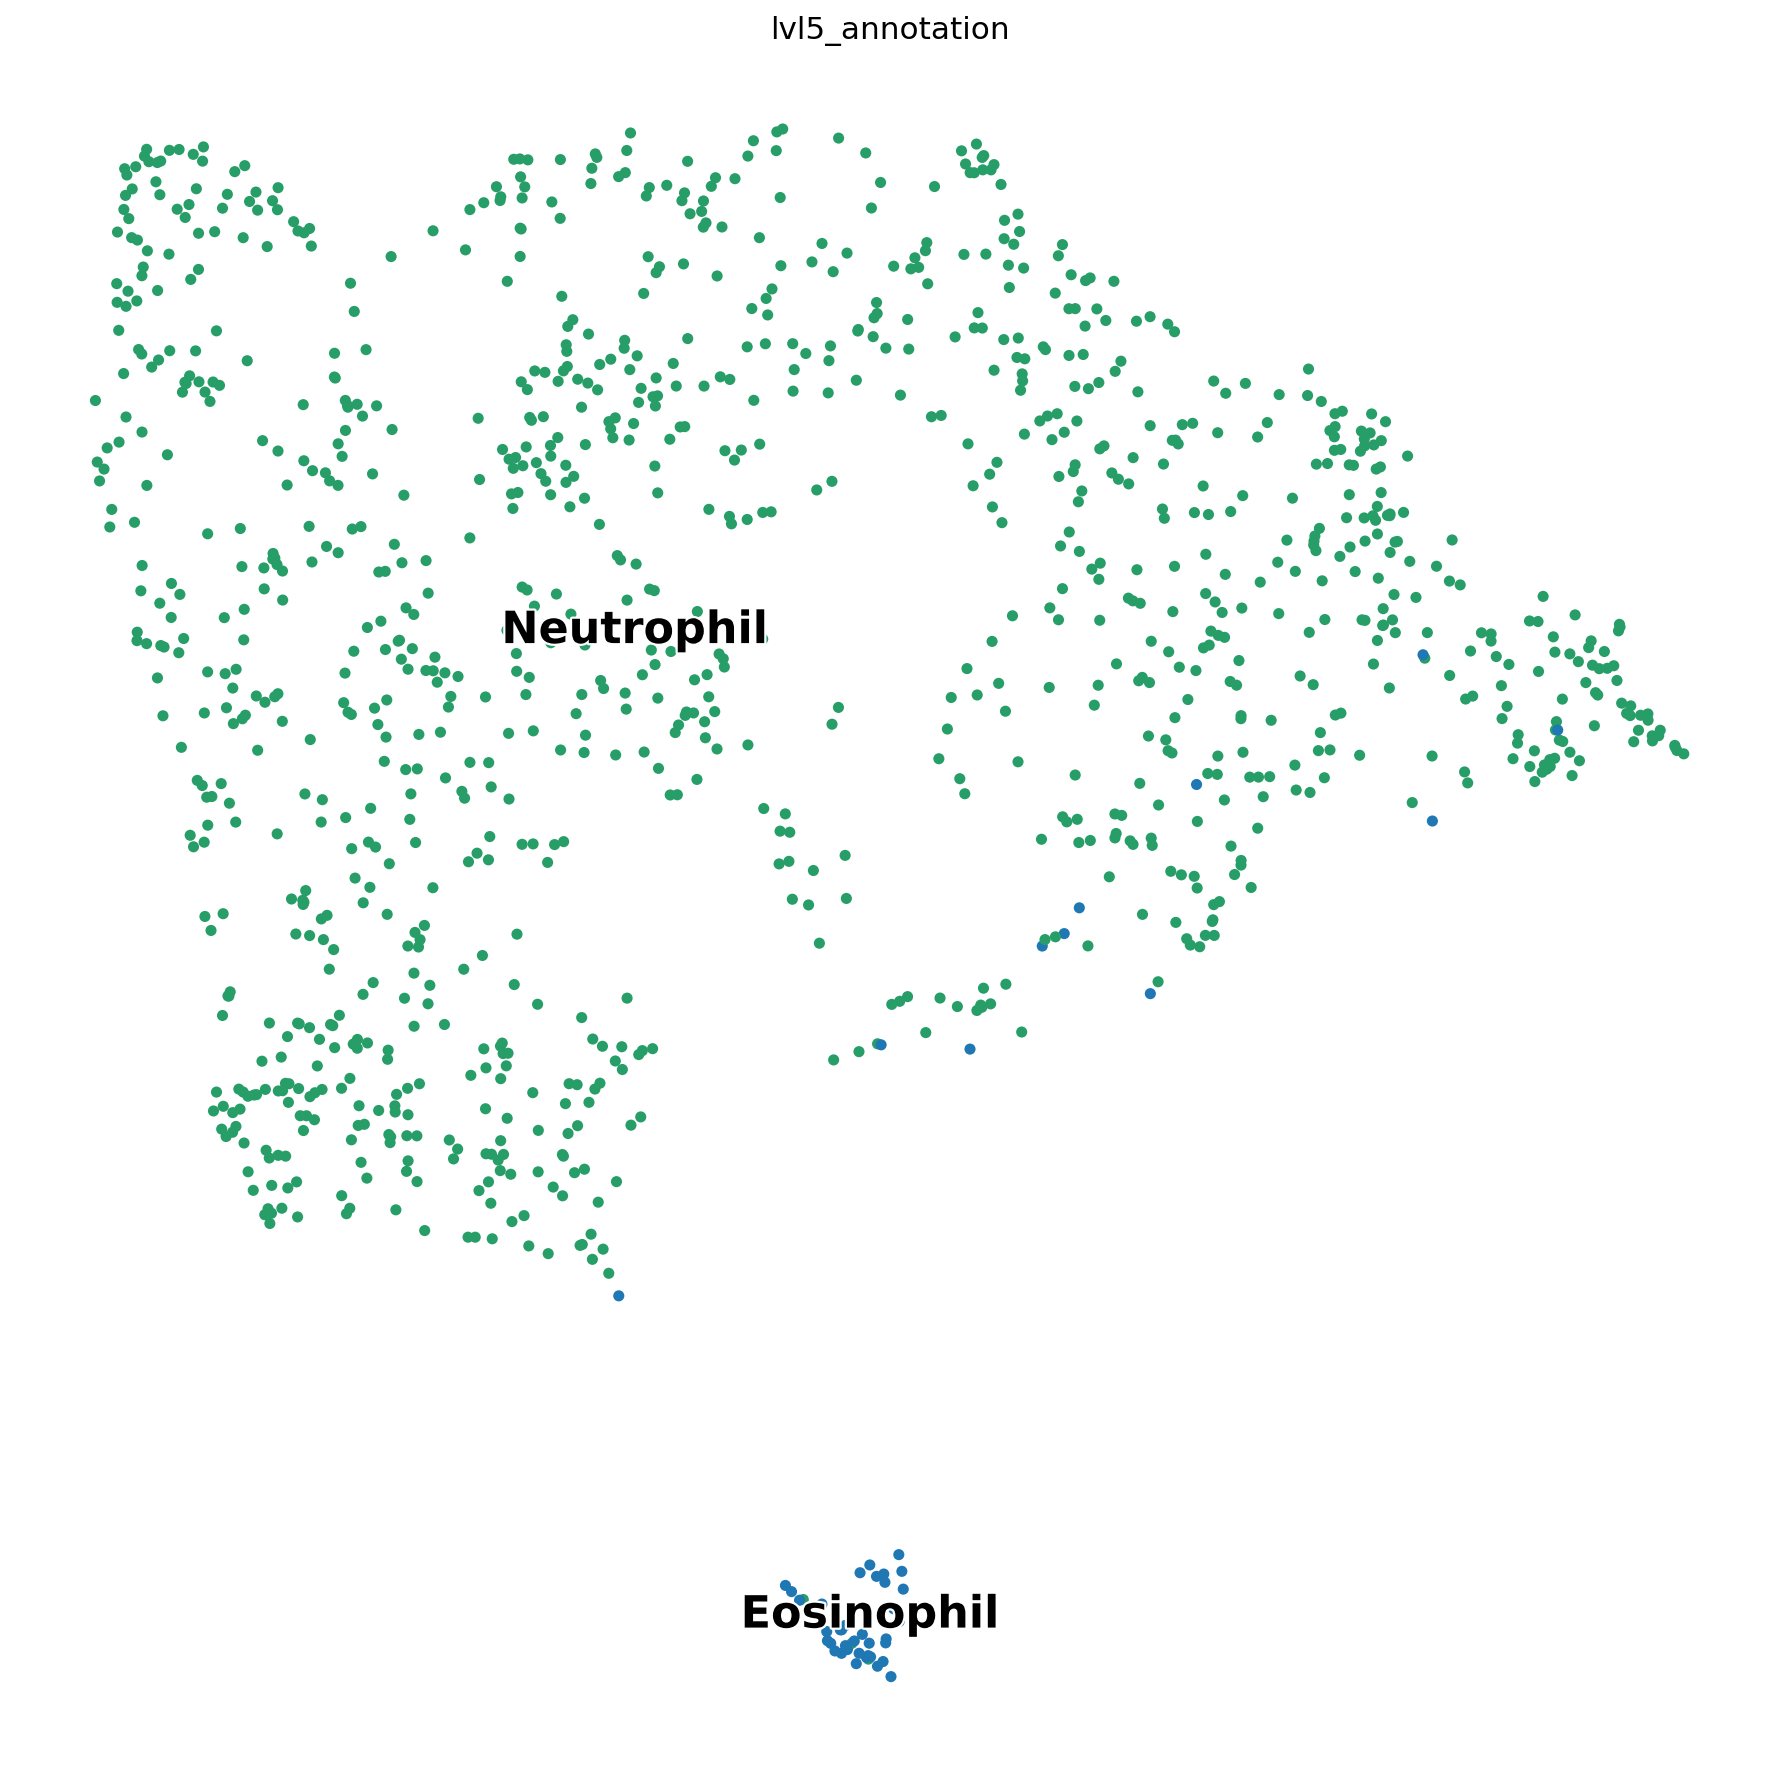

In [55]:
sc.pl.umap(
    adata,
    color=[
      'lvl5_annotation',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

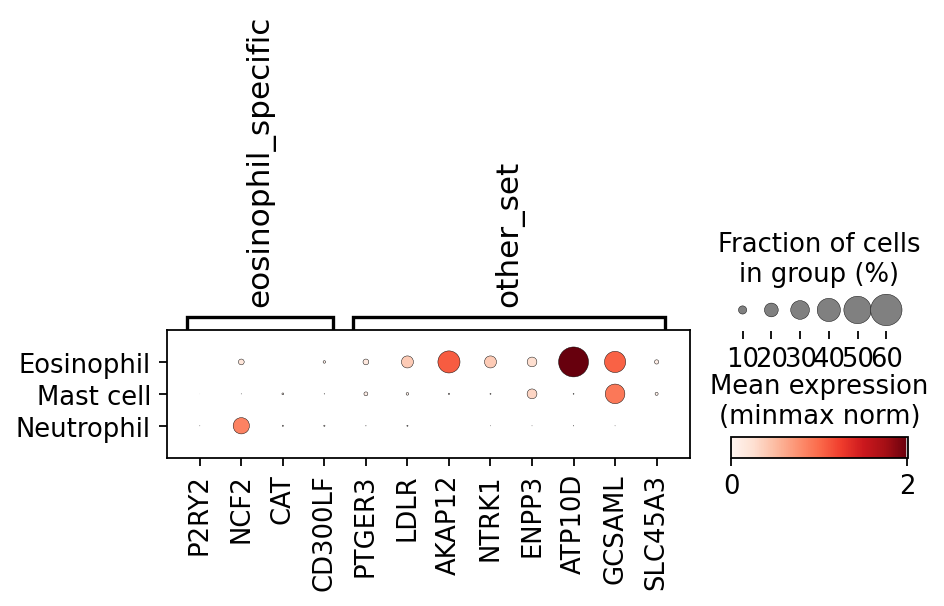

In [47]:
genes_dict = {
    "eosinophil_specific": ["P2RY2", "NCF2", "CAT", "CD300LF"],
    "other_set": ["PTGER3", "LDLR", "AKAP12", "NTRK1", "ENPP3", "ATP10D", "GCSAML", "SLC45A3"]
}

sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              genes_dict,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 

In [20]:
# CATEGORY="lvl5_annotation"

# try:
#     adata.obs["trm"] = adata.obs[CATEGORY].astype(str) + "__" +  adata.obs["Site_status"].astype(str)
#     #CATEGORY="lvl3_annotation_patient_status"
#     adata.obs["trm"].value_counts()
# except:
#     1

In [21]:
import gc
gc.collect()

975

In [22]:
# KEEP

In [23]:
# KEEP = adata_5k.obs['lvl5_annotation'].unique().tolist()
# KEEP=[x for x in KEEP if "prolif" not in x.lower()]
# adata=adata[adata.obs['lvl5_annotation'].isin(KEEP)].copy()

In [24]:
# adata.obs["Patient_status"].value_counts()

In [25]:
# adata_5k.obs["Site_status"].value_counts()

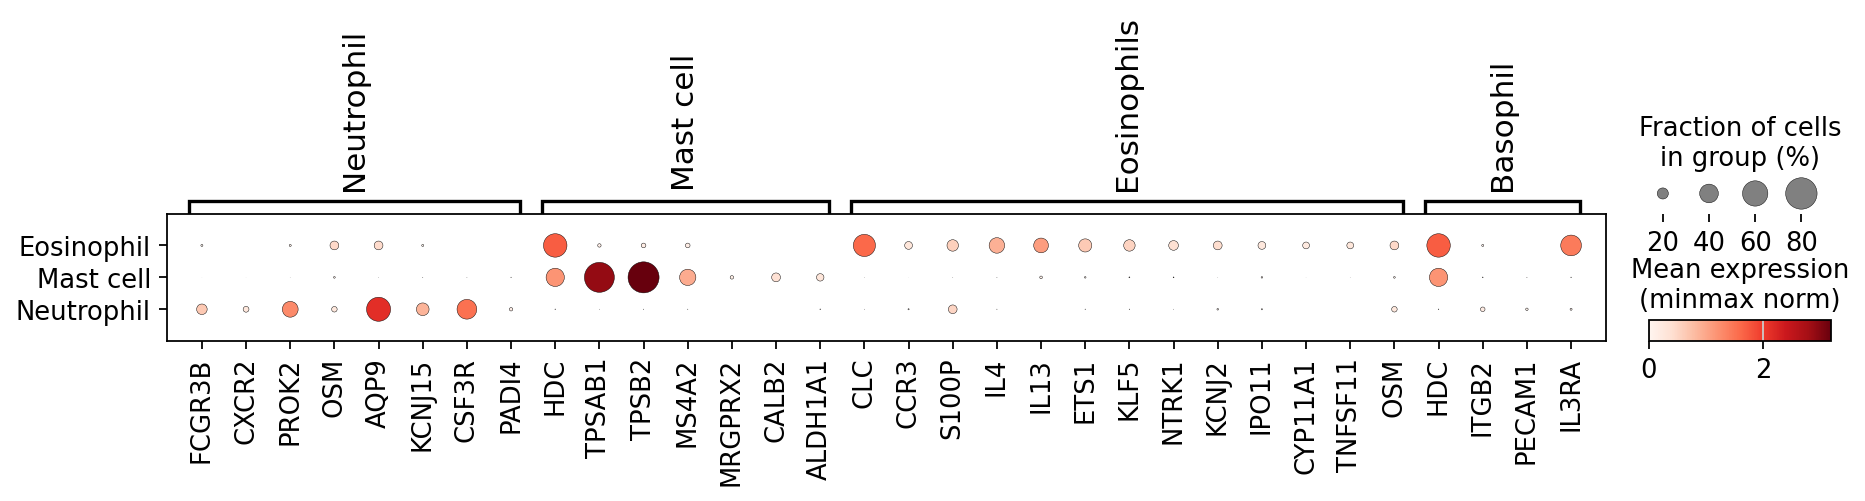

In [31]:
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )



# sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="Lesional"], 
#               remove_markers(["MCPT8", "HDC"],
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.3,
#               colorbar_title="Mean expression\n(minmax norm)",
#                             swap_axes=True,

#              )

 

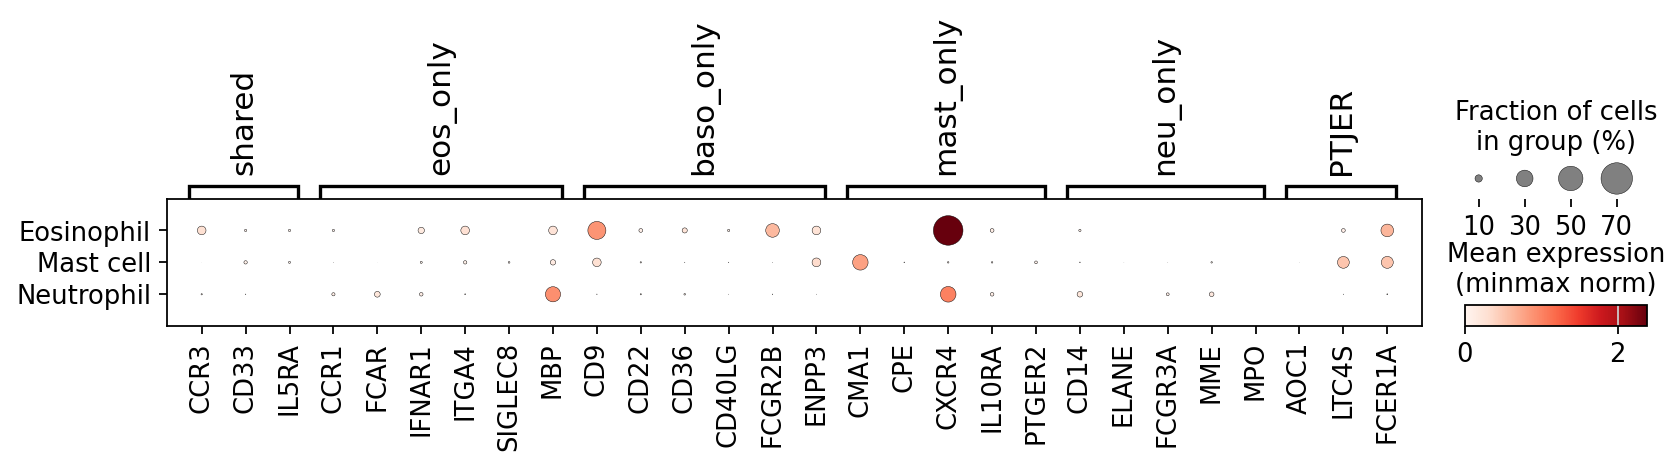

In [40]:
markers = {
 
}
sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              markers,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )


In [ ]:
stopaa

In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



In [10]:
CATEGORY="scanvi_pred_fine_curated"
import pandas as pd
#sc.tl.rank_genes_groups(adata, CATEGORY, method='wilcoxon', key_added="de_leiden");
df22 = pd.DataFrame(adata.uns['de_leiden']['names'])
for i,x in enumerate(df22.columns):
    print(i, x)

0 IC: Basophil
1 IC: Eosinophil
2 IC: Mast_cell_immature
3 IC: Mast_cell_mature
4 IC: Mast_cell_prog
5 P: Eo/Baso/mast_prog


In [35]:
select_population = list(df22.columns)[0
                                       
                                       
                                      ]  # JAW
print(select_population)
genes0 = df22[select_population][:50]
genes1 = df22[select_population][50:100]
genes2 = df22[select_population][100:150]
genes3 = df22[select_population][150:200]


# sc.pl.dotplot(
#     adata,
#     genes0,
#     groupby=CATEGORY,
#     standard_scale="var",
#     dendrogram=False, 
# )
# sc.pl.dotplot(
#     adata,
#     genes1,
#     groupby=CATEGORY,
#    standard_scale="var",
#     dendrogram=False, 
# ) 
# sc.pl.dotplot(
#     adata,
#     genes2,
#     groupby=CATEGORY,
#    standard_scale="var",
#     dendrogram=False, 
# ) 




IC: Basophil


In [ ]:
AREG, CLC, CD9, RFLNB, MAX, HSH2D, NDUFV2, NLK, FCGR2B

In [ ]:
sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="3D_Lesional_baseline"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
             aa   standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
adata_i.obs.tech.value_counts()

In [ ]:
1

In [ ]:
sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)



In [ ]:






sc.pl.dotplot(adata_i[adata_i.obs["tech"]!="xenium"], 
              remove_markers(["CCL1", "CCR8", "IL13"]),
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
            # save="supp1d_ccl1expression_scrna.pdf"
             )

sc.pl.dotplot(adata_i[adata_i.obs["tech"]=="xenium"], 
              ["CCL1", "CCR8", "IL13"],
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
ALL =   {'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1',
                                
                                     'CTSH',
  'VDR',
                                   ],

 'Th2': ['IL13', "CCL1", 'NBAS',# 'CCL17',
         'AREG', 'IL9R',# 'PDLIM4', 
         #'CCR8',
        # 'ZBTB16', 'KLRC4', 'ADGRG1',
         'RGS9',
        "SATB1", "PRDX2", "IL5",
         'IL22', 
        ]}

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

In [ ]:
# sc.pl.dotplot(adata, 
#               remove_markers(["IL4", "IL13"]),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.7,
#               colorbar_title="Mean expression\n(minmax norm)",
#               swap_axes=True,
#              #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
#             # save="supp1d_ccl1expression_scrna.pdf"
#              )

# sc.pl.dotplot(adata_5k, 
#               remove_markers(["IL4", "IL13"]),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.3,
#               colorbar_title="Mean expression\n(minmax norm)",
#                             swap_axes=True,
# #save='supp1d_ccl1expression_xenium.pdf'
#              #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
#              # save="supp1d_tdotplot.pdf"
#              )

sc.pl.dotplot(adata_i[adata_i.obs["tech"]!="xenium"], 
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
              colorbar_title="Mean expression\n(log1p norm)",
            #  swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
            # save="supp1d_ccl1expression_scrna.pdf"
             )
sc.pl.dotplot(adata_i[adata_i.obs["tech"]=="xenium"], 
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(log1p norm)",
                 #           swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 
adata_xenium_i = adata_i[adata_i.obs["tech"]=="xenium"]
sc.pl.dotplot(adata_xenium_i[adata_xenium_i.obs["niche19"].str.startswith("Epi")],
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(log1p norm)",
                 #           swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
adata_5k.obs["lvl5_annotation"].value_counts()

In [ ]:
# stop

# try with ptgds

In [ ]:
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.v8_nohealthy')
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna'
adata=sc.read_h5ad(PATH)
#adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
#adata=adata[adata.obs["tech"]!="xenium"].copy()

#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()

In [90]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



In [ ]:
sc.pl.dotplot(adata, 
              ["CCL1", "CCR8", "PTGDS"],
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.7,
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
         #    save="supp1d_ccl1expression_scrna.pdf"
             )
 